<a href="https://colab.research.google.com/github/SSenitha/Data_Analytics/blob/Sandaru's/Copy_of_Group_02_MasterNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analysis of Rain in Australia**

This notebook contains all the steps of the analysis: From data cleaning and preprocessing to the conclusions.

In [457]:
# Load data from the repository
!wget https://raw.githubusercontent.com/SSenitha/Data_Analytics/main/weatherAUS.csv

--2025-09-18 15:23:27--  https://raw.githubusercontent.com/SSenitha/Data_Analytics/main/weatherAUS.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14094055 (13M) [text/plain]
Saving to: ‘weatherAUS.csv.11’

weatherAUS.csv.11   100%[===================>]  13.44M  --.-KB/s    in 0.1s    

2025-09-18 15:23:27 (118 MB/s) - ‘weatherAUS.csv.11’ saved [14094055/14094055]



In [458]:
#Import necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import stats

#Data Cleaning

In [459]:
# Read the dataset and output the total count
df = pd.read_csv('/content/weatherAUS.csv')
print(f"Total rows count: {df['RainToday'].count()}")
df.head()

Total rows count: 142199


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## De-duplication

In [450]:
# Check for duplicate rows and removing, keeping the first occurrence
print(df.duplicated().sum())
df_cleaned = df.drop_duplicates()

0


##Null Value Handeling

In [451]:
# Check for the missing values
missing_values_count = df.isnull().sum()
print(missing_values_count)

# Calculate the percent of data that is missing
total_cells = np.prod(df.shape)
total_missing = missing_values_count.sum()

percent_missing = (total_missing/total_cells) * 100
print(f"Percentage of missing values: {percent_missing}")

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64
Percentage of missing values: 10.259745694319072


In [452]:
df_cleaned = df.copy()

# Remove the rows that has missing result
df_cleaned.dropna(subset=['RainToday'], inplace=True)
df_cleaned.dropna(subset=['RainTomorrow'], inplace=True)
#print(df.head())

# Check the remaining value count
print(f"Total rows Left: {df['RainToday'].count()}")

Total rows Left: 142199


In [421]:
numerical_cols = df.select_dtypes(include=['float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna('')

##Standardization

In [422]:
# convert the date column into a datetime object
df_cleaned['Date'] = pd.to_datetime(df['Date'], format="%Y-%m-%d")

# extract the day, month, and year components
df_cleaned['Day'] = df_cleaned['Date'].dt.day
df_cleaned['Month'] = df_cleaned['Date'].dt.month
df_cleaned['Year'] = df_cleaned['Date'].dt.year

In [423]:
#Removing unwanted columns
df_cleaned.drop(['WindDir9am'], axis=1, inplace=True)
df_cleaned.drop(['WindDir3pm'], axis=1, inplace=True)

In [379]:
# Map binary variables
df_cleaned['RainTomorrow'] = df_cleaned['RainTomorrow'].map({'Yes': 1, 'No': 0})
df_cleaned['RainToday'] = df_cleaned['RainToday'].map({'Yes': 1, 'No': 0})

In [380]:
df_cleaned.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindSpeed9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Day,Month,Year
0,2008-12-01,Albury,13.4,22.9,0.6,4.8,8.5,W,44.0,20.0,...,1007.1,8.0,5.0,16.9,21.8,0,0,1,12,2008
1,2008-12-02,Albury,7.4,25.1,0.0,4.8,8.5,WNW,44.0,4.0,...,1007.8,5.0,5.0,17.2,24.3,0,0,2,12,2008
2,2008-12-03,Albury,12.9,25.7,0.0,4.8,8.5,WSW,46.0,19.0,...,1008.7,5.0,2.0,21.0,23.2,0,0,3,12,2008
3,2008-12-04,Albury,9.2,28.0,0.0,4.8,8.5,NE,24.0,11.0,...,1012.8,5.0,5.0,18.1,26.5,0,0,4,12,2008
4,2008-12-05,Albury,17.5,32.3,1.0,4.8,8.5,W,41.0,7.0,...,1006.0,7.0,8.0,17.8,29.7,0,0,5,12,2008


# **Descriptive Analysis**

In [381]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140787 entries, 0 to 145458
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           140787 non-null  datetime64[ns]
 1   Location       140787 non-null  object        
 2   MinTemp        140787 non-null  float64       
 3   MaxTemp        140787 non-null  float64       
 4   Rainfall       140787 non-null  float64       
 5   Evaporation    140787 non-null  float64       
 6   Sunshine       140787 non-null  float64       
 7   WindGustDir    140787 non-null  object        
 8   WindGustSpeed  140787 non-null  float64       
 9   WindSpeed9am   140787 non-null  float64       
 10  WindSpeed3pm   140787 non-null  float64       
 11  Humidity9am    140787 non-null  float64       
 12  Humidity3pm    140787 non-null  float64       
 13  Pressure9am    140787 non-null  float64       
 14  Pressure3pm    140787 non-null  float64       
 15  Cloud


*   We can see that the dataset contains mixture of categorical and numerical variables.
*   Categorical variables have data type object.


*   Numerical variables have data type float64.
*   Also, there are some missing values in the dataset.


**Change the data type 'object' to 'category'** - This helps to tell Python/statistics that it’s a categorical variable, improves memory, speed, and modeling.

In [382]:
# create a copy of a cleaned data set
df_copy = df_cleaned.copy(deep=True)

 #Remove unwanted column
df_copy.drop(['WindGustDir'], axis=1, inplace=True)
df_copy.drop(['Date'], axis=1, inplace=True)

In [383]:
df_copy.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Day,Month,Year
0,Albury,13.4,22.9,0.6,4.8,8.5,44.0,20.0,24.0,71.0,...,1007.1,8.0,5.0,16.9,21.8,0,0,1,12,2008
1,Albury,7.4,25.1,0.0,4.8,8.5,44.0,4.0,22.0,44.0,...,1007.8,5.0,5.0,17.2,24.3,0,0,2,12,2008
2,Albury,12.9,25.7,0.0,4.8,8.5,46.0,19.0,26.0,38.0,...,1008.7,5.0,2.0,21.0,23.2,0,0,3,12,2008
3,Albury,9.2,28.0,0.0,4.8,8.5,24.0,11.0,9.0,45.0,...,1012.8,5.0,5.0,18.1,26.5,0,0,4,12,2008
4,Albury,17.5,32.3,1.0,4.8,8.5,41.0,7.0,20.0,82.0,...,1006.0,7.0,8.0,17.8,29.7,0,0,5,12,2008


In [384]:
# Identify object dtype columns
object_cols = df_copy.select_dtypes(include=['object']).columns

# Convert object columns to category
df_copy[object_cols] = df_copy[object_cols].astype('category')

# Check updated dtypes
print(df_copy.dtypes)

Location         category
MinTemp           float64
MaxTemp           float64
Rainfall          float64
Evaporation       float64
Sunshine          float64
WindGustSpeed     float64
WindSpeed9am      float64
WindSpeed3pm      float64
Humidity9am       float64
Humidity3pm       float64
Pressure9am       float64
Pressure3pm       float64
Cloud9am          float64
Cloud3pm          float64
Temp9am           float64
Temp3pm           float64
RainToday           int64
RainTomorrow        int64
Day                 int32
Month               int32
Year                int32
dtype: object


In [385]:
df_copy.shape

(140787, 22)

In [386]:
df_copy.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Day,Month,Year
0,Albury,13.4,22.9,0.6,4.8,8.5,44.0,20.0,24.0,71.0,...,1007.1,8.0,5.0,16.9,21.8,0,0,1,12,2008
1,Albury,7.4,25.1,0.0,4.8,8.5,44.0,4.0,22.0,44.0,...,1007.8,5.0,5.0,17.2,24.3,0,0,2,12,2008
2,Albury,12.9,25.7,0.0,4.8,8.5,46.0,19.0,26.0,38.0,...,1008.7,5.0,2.0,21.0,23.2,0,0,3,12,2008
3,Albury,9.2,28.0,0.0,4.8,8.5,24.0,11.0,9.0,45.0,...,1012.8,5.0,5.0,18.1,26.5,0,0,4,12,2008
4,Albury,17.5,32.3,1.0,4.8,8.5,41.0,7.0,20.0,82.0,...,1006.0,7.0,8.0,17.8,29.7,0,0,5,12,2008


**View statistical properties of dataset**

In [387]:
df_copy.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Day,Month,Year
count,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,...,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000
mean,12.184209,23.233735,2.349974,5.187367,8.043108,39.907754,13.983074,18.637772,68.839474,51.462983,...,1015.252294,4.643788,4.698765,16.985729,21.682127,0.223423,0.221618,15.714704,6.403482,2012.757492
std,6.393235,7.106800,8.465173,3.196637,2.775557,13.133963,8.853265,8.718790,18.961051,20.547147,...,6.682548,2.300772,2.123656,6.480890,6.873294,0.416541,0.415337,8.798882,3.426583,2.542272
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,...,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000,0.000000,1.000000,1.000000,2007.000000
25%,7.600000,17.900000,0.000000,4.000000,8.200000,31.000000,7.000000,13.000000,57.000000,37.000000,...,1011.000000,3.000000,4.000000,12.300000,16.700000,0.000000,0.000000,8.000000,3.000000,2011.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,...,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000,0.000000,16.000000,6.000000,2013.000000
75%,16.800000,28.200000,0.800000,5.400000,8.700000,46.000000,19.000000,24.000000,83.000000,65.000000,...,1019.400000,6.000000,6.000000,21.500000,26.300000,0.000000,0.000000,23.000000,9.000000,2015.000000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,...,1039.600000,9.000000,9.000000,40.200000,46.700000,1.000000,1.000000,31.000000,12.000000,2017.000000


>Data Completeness and Scale

The dataset demonstrates robust data collection with 140,787 complete observations for most meteorological variables, though temporal features (Day, Month, Year) show reduced counts at 55,553 observations. This substantial sample size spanning from 2007 to 2017 provides a decade-long view of Australian weather patterns, offering sufficient statistical power for reliable predictive modeling. The consistent count across primary weather variables suggests good data quality management in the core meteorological measurements, which is crucial for building trustworthy rain prediction models.

>Temperature Dynamics

The temperature statistics reveal Australia's characteristic continental climate with extreme variability. The minimum temperature averaging 12.2°C with a range from -8.5°C to 33.9°C, alongside maximum temperatures averaging 23.2°C but reaching up to 48.1°C, illustrates the harsh temperature extremes typical of Australian inland regions. The standard deviations of 6.4°C for minimum and 7.1°C for maximum temperatures indicate substantial daily and seasonal fluctuations. The diurnal temperature pattern is clearly evident with morning temperatures at 9am averaging 16.9°C, rising to 21.7°C by 3pm, representing a consistent 4.8°C warming throughout the day. This temperature progression, combined with the wide ranges, suggests the dataset captures diverse climatic zones from coastal to inland desert regions.

>Rainfall Distribution

The rainfall statistics paint a picture of Australia's predominantly dry climate with intermittent extreme precipitation events. With a mean of only 2.35mm but a maximum of 371mm, the data exhibits severe right skewness characteristic of arid and semi-arid climates. Most tellingly, the median rainfall is 0mm, and even the 75th percentile reaches only 0.8mm, indicating that more than 75% of days experience little to no rainfall. This distribution pattern is typical of Australia's climate where extended dry periods are punctuated by intense rainfall events, often associated with tropical systems or severe storms. The standard deviation of 8.47mm, much larger than the mean, further confirms this highly variable precipitation pattern that makes rain prediction particularly challenging yet crucial for water resource management.

>Humidity Patterns

The humidity measurements reveal distinct diurnal moisture cycling critical for understanding precipitation potential. Morning humidity at 9am averages 68.8% with a standard deviation of 18.96%, indicating generally moist morning conditions with considerable variability. By 3pm, humidity drops significantly to an average of 51.5% (std: 20.55%), representing a mean decrease of 17.3 percentage points. This consistent afternoon drying pattern reflects the typical atmospheric moisture cycle where morning stability gives way to afternoon convective mixing. The wider standard deviation in afternoon humidity suggests more variable atmospheric conditions later in the day, possibly influenced by local weather systems, sea breezes, or convective development. The range from 0% to 100% for both measurements indicates the dataset captures everything from desert-dry to saturated conditions.

>Atmospheric Pressure

The pressure readings demonstrate relatively stable atmospheric conditions with subtle but important variations. Mean pressure at 9am (1017.6 hPa) dropping slightly to 1015.3 hPa by 3pm represents a typical diurnal pressure pattern. The consistent standard deviation of approximately 6.7 hPa for both times suggests uniform pressure variability throughout the day. The minimum values around 980 hPa indicate the passage of significant low-pressure systems, likely associated with rain-bearing fronts or tropical cyclones. The 25th percentile values (1013.5 hPa at 9am, 1011.0 hPa at 3pm) could serve as useful thresholds for identifying approaching weather systems. This 2.3 hPa average daily decrease, while small, is meteorologically significant and reflects atmospheric heating and convective processes.

>Wind Patterns

Wind statistics reveal complex atmospheric dynamics with significant diurnal intensification. Wind gusts averaging 39.9 km/h with a maximum of 135 km/h indicate exposure to severe weather events, possibly including tropical cyclones or severe thunderstorms. The progression from calm morning winds (mean 13.98 km/h at 9am) to stronger afternoon winds (18.64 km/h at 3pm) reflects typical boundary layer development as surface heating increases atmospheric mixing. The high standard deviations (8.85 km/h for 9am, 8.72 km/h for 3pm) suggest variable wind conditions influenced by diverse geographic features and weather systems. The 75th percentile wind gust speed of 46 km/h indicates that strong winds are relatively common, occurring at least 25% of the time, which could influence evaporation rates and precipitation patterns.

> Sunshine and Evaporation

Sunshine hours averaging 8.04 hours with a standard deviation of 2.78 hours confirms Australia's reputation as a sunny continent. The 25th percentile at 8.2 hours suggests that even the lower quartile of days receives substantial sunshine, indicating predominantly clear or partly cloudy conditions. Evaporation rates averaging 5.19mm daily with high variability (std: 3.20mm) and extreme maximum of 145mm reflect the intense evaporative demand of the Australian climate. The strong sunshine combined with high evaporation rates creates a moisture deficit that must be overcome for precipitation to occur. The relatively narrow interquartile range for sunshine (8.2 to 8.7 hours) suggests consistent solar radiation input, making deviations potentially significant for weather prediction.

> Cloud Cover Persistence

Cloud cover statistics show remarkable consistency between morning and afternoon observations, both averaging approximately 4.6-4.7 oktas with similar standard deviations around 2.2 oktas. This persistence suggests that cloud patterns, once established, tend to maintain throughout the day rather than showing strong diurnal variation like other parameters. The median values of 5.0 oktas for both times indicate that partly to mostly cloudy conditions are typical. The 75th percentile at 6.0 oktas represents significantly cloudy conditions that could be associated with approaching weather systems. The maximum of 9.0 oktas (complete overcast) and minimum of 0.0 (clear sky) show the full range of cloud conditions are captured, providing valuable information for precipitation prediction.

>Seasonal Representation

The temporal variables reveal comprehensive coverage across the study period from 2007 to 2017, providing a robust long-term dataset that captures inter-annual climate variability. The mean month value of 6.49 and mean day of 6.38 (with standard deviations of 3.45 and 3.43 respectively) indicate uniform sampling across all seasons and days, ensuring no temporal bias in the dataset. This even distribution is crucial for developing models that can predict rain throughout the year, accounting for seasonal patterns from wet summers to dry winters depending on the region. The year range allows for investigation of climate trends and ensures the model training captures various climate phases.

>Implications for Rain Prediction Modeling

The statistical profile reveals several key insights for developing rain prediction models. The extreme skewness in rainfall distribution suggests that rain/no-rain classification might be more appropriate than regression approaches for precipitation amounts. The strong diurnal patterns in humidity, temperature, and wind indicate that afternoon measurements, particularly humidity at 3pm dropping below 50% or remaining above 65%, could be powerful predictors. The relatively stable pressure patterns mean that deviations from normal (particularly readings below 1011 hPa) become significant indicators of weather change. The persistence of cloud cover throughout the day suggests that morning cloud observations could provide early warning of precipitation potential. The combination of high temperature variability, low median rainfall, and high evaporation rates creates a challenging prediction environment where multiple atmospheric variables must align for precipitation to occur, necessitating sophisticated multivariate modeling approaches that can capture these complex interactions.

**Explore *RainTomorrow* target variable**

Check for missing values



In [388]:
# Count null values in target variable
null_count = df_copy['RainTomorrow'].isnull().sum()

print(f"Number of null values in RainTomorrow: {null_count}")


Number of null values in RainTomorrow: 0


View the unique values

In [389]:
df_copy['RainTomorrow'].unique()

array([0, 1])

View the frequency distribution of values

In [353]:
df_copy['RainTomorrow'].value_counts()

,count
RainTomorrow,


In [354]:
df_copy['RainTomorrow'].value_counts()/len(df)

,count
RainTomorrow,




*   We can see that out of the total number of RainTomorrow values, No(0)  appears 77.83% times and Yes(1) appears 22.16% times.



## **Categorical Variables Analysis**

In [355]:
import plotly.express as px
from tqdm import tqdm

***Visualize frequency distribution of RainTomorrow variable***

> In the charts below, "RainTomorrow = Yes" is represented by '1' and "RainTomorrow = No" is represented by '0'.





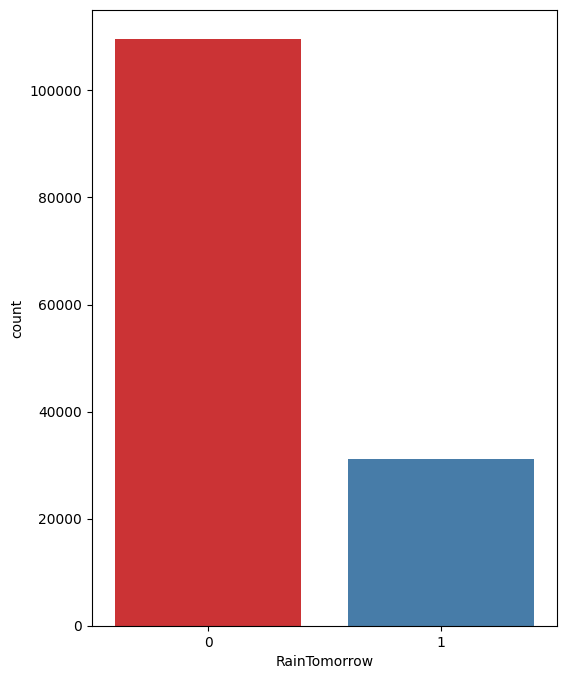

In [213]:
f, ax = plt.subplots(figsize=(6, 8))
ax = sns.countplot(x="RainTomorrow", data=df_copy, palette="Set1", hue="RainTomorrow", legend=False)
plt.show()



*   The No (0) variable have 109586 entries, and
*   The Yes (1) variable have 31201
entries.



***Location vs RainTomorrow (grouped by Yes/No)***

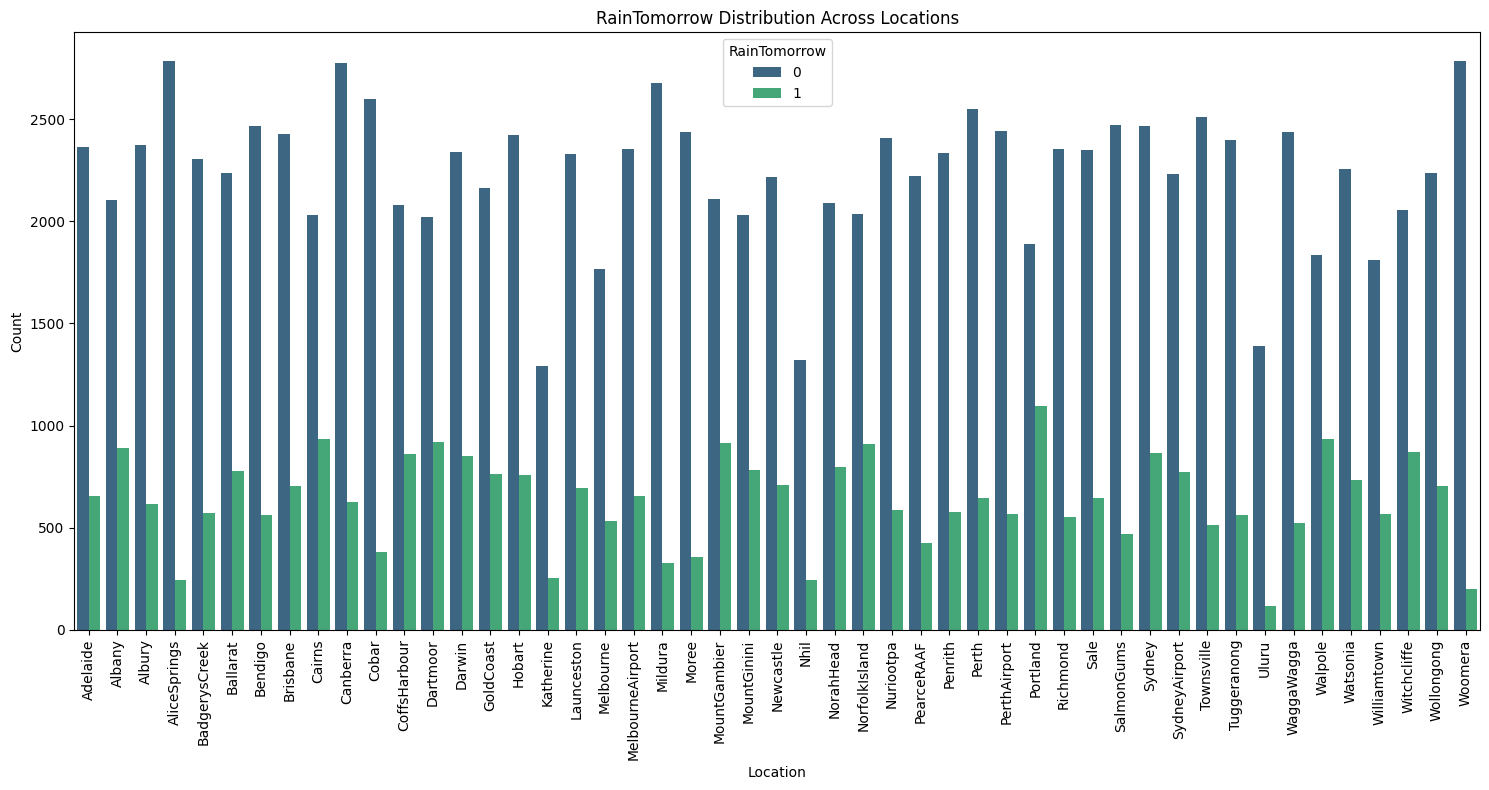

In [214]:
plt.figure(figsize=(15, 8))
sns.countplot(data=df_copy, x='Location', hue='RainTomorrow', palette='viridis')

plt.ylabel('Count')
plt.xticks(rotation=90)
plt.title('RainTomorrow Distribution Across Locations')
plt.tight_layout()
plt.show()

* The chart displays the number of days each location was predicted to have rain ("Yes" - 1) or no rain ("No" - 0) tomorrow. The blue bars represent "No" and the green bars represent "Yes." The height of each bar corresponds to the count of days.

 * For nearly all locations, the count of "No" rain days (blue bars) is significantly higher than the count of "Yes" rain days (green bars). This indicates that across the dataset, it was more common for the forecast to predict no rain than rain.

 * Sydney, Canberra, and Melbourne appear to have the highest number of days with a "RainTomorrow: Yes" prediction. This could imply that these major cities experienced more frequent rainfall or that more data was collected for them.

 * In contrast, locations like Woomera, Watsonia, Walpole, and Cobar have very low "RainTomorrow: Yes" counts. This could indicate a drier climate in these regions or fewer total data points.

 * The visualization effectively highlights the uneven distribution of rain events across different Australian locations within the given time frame. It suggests that while no rain is the more frequent forecast overall, the actual frequency of rain predictions varies substantially depending on the location.

***RainToday vs RainTomorrow (to see correlation between consecutive days)***

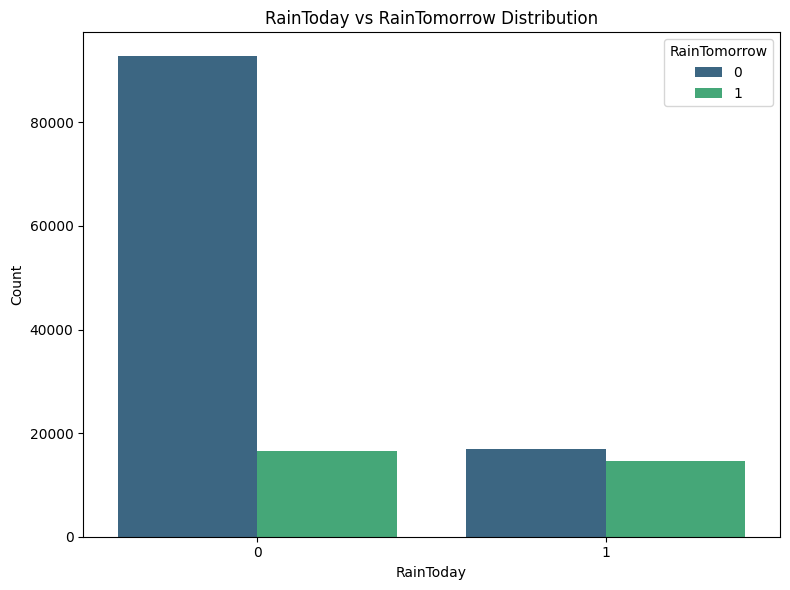

In [390]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_copy, x='RainToday', hue='RainTomorrow', palette='viridis')

plt.ylabel('Count')
plt.title('RainToday vs RainTomorrow Distribution')
plt.tight_layout()
plt.show()

* The largest bar in the entire chart represents days where it did not rain today ("RainToday: No") and is also predicted to not rain tomorrow ("RainTomorrow: No"). This shows that in the majority of cases, a dry day is followed by another dry day.

* A much smaller bar represents days where it did not rain today ("RainToday: No") but is predicted to rain tomorrow ("RainTomorrow: Yes"). This indicates that a dry day is less likely to be followed by a rainy day.

* The two bars on the right show the distribution when it did rain today. The blue bar represents "RainTomorrow: No" and the green bar represents "RainTomorrow: Yes."

* The heights of these two bars are relatively similar, though the "RainTomorrow: Yes" bar is slightly larger. This is a very important insight. It suggests that if it rains today, the chances of it raining tomorrow are roughly equal to, or slightly higher than, the chances of it not raining.

* Comparing these bars to the "RainToday: No" bars, we see a dramatic shift. When "RainToday" is "Yes," the proportion of "RainTomorrow: Yes" predictions is significantly higher than when "RainToday" is "No."

***Monthly rain patterns (Month vs RainTomorrow percentage)***

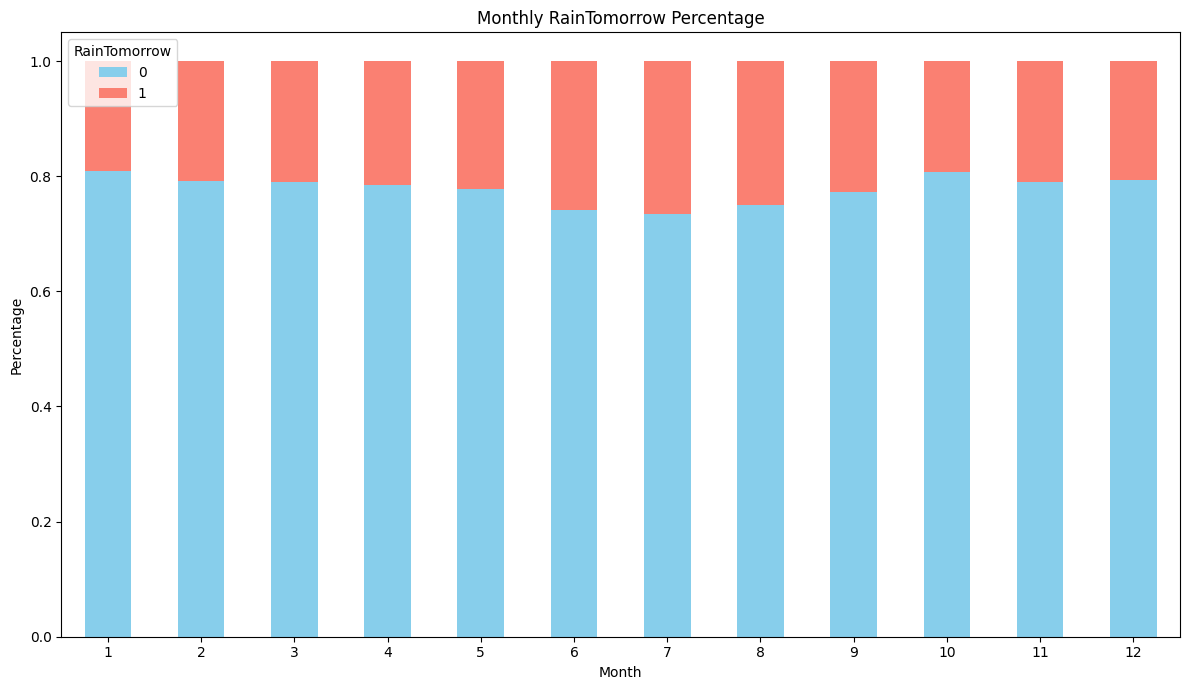

In [391]:
# Calculate the count of RainTomorrow for each month
# Fill missing values in 'Month' with a placeholder before grouping
monthly_rain = df_copy.groupby(['Month', 'RainTomorrow'], observed=False).size().unstack(fill_value=0)

# Calculate the percentage of RainTomorrow for each month
monthly_rain_percent = monthly_rain.apply(lambda x: x / x.sum(), axis=1)

# Create a stacked bar chart
monthly_rain_percent.plot(kind='bar', stacked=True, figsize=(12, 7), color=['skyblue', 'salmon'])

plt.title('Monthly RainTomorrow Percentage')
plt.xlabel('Month')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='RainTomorrow', loc='upper left')
plt.tight_layout()
plt.show()

* This stacked bar chart shows how many days in each month, over the 10-year period from 2007 to 2017, were predicted to have rain ("Yes") or no rain ("No") on the following day.

* The chart reveals a clear seasonal pattern in rainfall predictions. The number of "RainTomorrow: Yes" predictions (green bars) is significantly higher during the cooler months of the Australian year (April to October), with a peak around June and July. This aligns with the fact that many parts of southern Australia receive more rainfall during winter.

* For all months, the count of "RainTomorrow: No" predictions (blue bars) is substantially higher than the "Yes" predictions. This highlights a significant class imbalance in the dataset, meaning that dry days are far more common than rainy days.

* The total height of the bars (sum of "Yes" and "No" counts) is relatively consistent across all months, indicating that the dataset has a similar number of observations for each month. This suggests the data collection process was consistent over the period.

***Yearly trends (Year vs RainTomorrow percentage)***

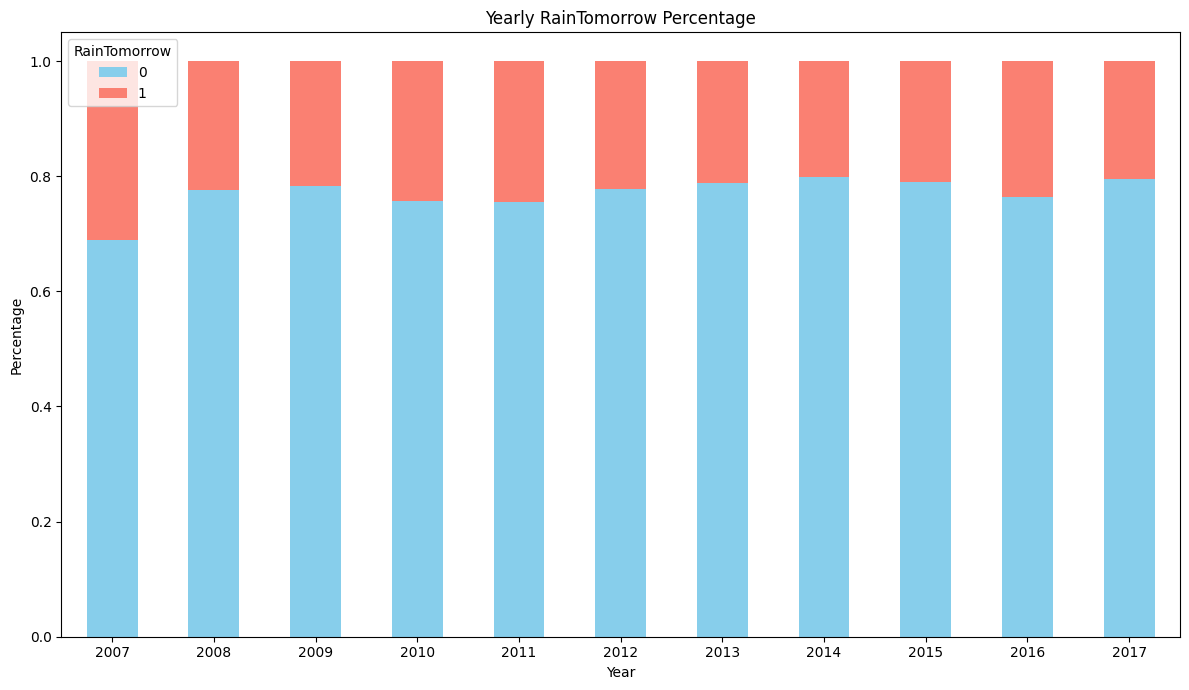

In [392]:
# Calculate the count of RainTomorrow for each year
yearly_rain = df_copy.groupby(['Year', 'RainTomorrow'], observed=False).size().unstack(fill_value=0)

# Calculate the percentage of RainTomorrow for each year
yearly_rain_percent = yearly_rain.apply(lambda x: x / x.sum(), axis=1)

# Create a stacked bar chart
yearly_rain_percent.plot(kind='bar', stacked=True, figsize=(12, 7), color=['skyblue', 'salmon'])

plt.title('Yearly RainTomorrow Percentage')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='RainTomorrow', loc='upper left')
plt.tight_layout()
plt.show()

* For every year from 2007 to 2017, the percentage of "RainTomorrow: No" (blue) is significantly higher than "RainTomorrow: Yes" (red/salmon). This reinforces the finding from other charts that the dataset has a considerable class imbalance, with no-rain days being much more common than rainy days.

* The proportion of "Yes" and "No" predictions remains fairly stable across the entire period. There are no dramatic spikes or drops in the percentage of rain predictions from one year to the next.
   

    * The "No" percentage consistently hovers between roughly 75% and 80%.
    * The "Yes" percentage remains between 20% and 25%.

* While stable, there are some small fluctuations:

    * The percentage of "Yes" predictions appears to be slightly higher in 2007 and 2010.
    * The percentage of "Yes" predictions is slightly lower and the "No" percentage is slightly higher in 2013, 2014, and 2015, suggesting these years might have been slightly drier on average within the dataset.

* The chart suggests that over the 10-year period, there was no drastic shift in the overall frequency of rainy days across Australia as represented by this dataset. The general weather patterns remained relatively consistent from a macro perspective.

# **Numerical Variables Distribution**

16it [00:31,  1.96s/it]


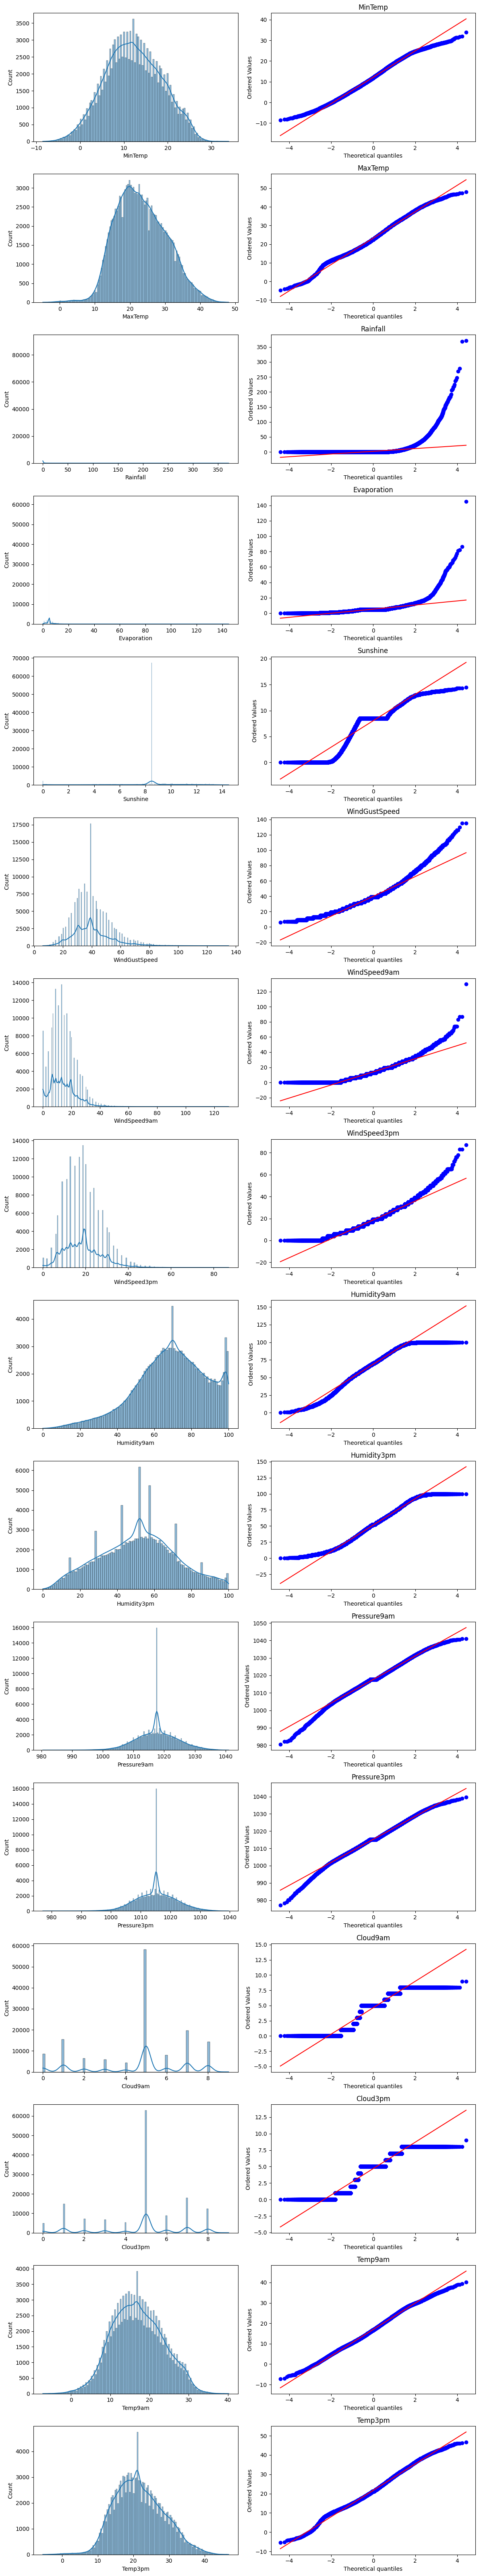

In [393]:
from tqdm import tqdm
from scipy import stats

numerical_features = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features)*4))

for i, col in tqdm(enumerate(numerical_features)):
    sns.histplot(df_copy[col], ax = axes[i, 0], kde =True)
    stats.probplot(df_copy[col].dropna(), dist='norm', plot=axes[i, 1])
    axes[i, 1].set_title(col)

plt.tight_layout()
plt.show()

* Temperature and pressure variables display approximately normal distributions with minimal outliers. MinTemp, MaxTemp, Temp9am, Temp3pm, and both pressure variables follow bell-shaped curves that are close to normal distribution. The Q-Q plots confirm good normality for these variables, with data points closely following the diagonal line. However, some extreme temperature outliers exist, likely representing unusually hot or cold days. Humidity variables show bimodal (double-peak) distributions rather than normal curves, suggesting distinct dry and wet weather patterns, with outliers at both very low and very high humidity levels.

* Weather intensity variables are heavily right-skewed and non-normal with significant outliers throughout. Rainfall shows a highly non-normal distribution with most days having little to no rain, but extreme outliers representing heavy rainfall events and storms. WindGustSpeed, Evaporation, and Sunshine all follow similar non-normal patterns with numerous high-value outliers indicating severe weather conditions like strong winds, extreme heat, or drought. The Q-Q plots clearly show these variables departing from the diagonal line, especially in the upper quantiles, confirming their non-normality. Cloud cover variables are more uniformly distributed but still non-normal with outliers at both zero cloud cover (clear skies) and maximum cloud cover (overcast conditions). These non-normal distributions and extensive outliers in weather intensity variables capture the natural variability and extreme weather events that would be crucial predictors for rainfall forecasting.

***Rainfall distribution by RainTomorrow***

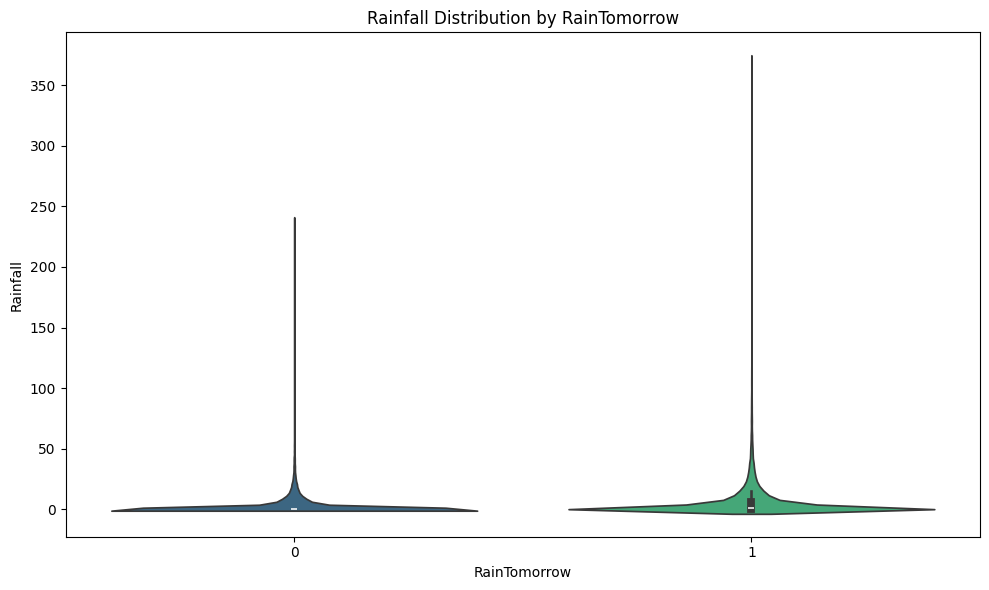

In [219]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_copy, x='RainTomorrow', y='Rainfall', palette='viridis', hue='RainTomorrow', legend=False)
plt.title('Rainfall Distribution by RainTomorrow')
plt.xlabel('RainTomorrow')
plt.ylabel('Rainfall')
plt.tight_layout()
plt.show()

* This plot suggests there's a relationship between current rainfall and tomorrow's rain forecast. Days with very little current rainfall are more likely to have no rain tomorrow, while days with more current rainfall show greater variability in tomorrow's forecast.

* However, both categories show significant overlap, indicating that current rainfall alone isn't a perfect predictor of tomorrow's weather.

***Temperature variables (MinTemp, MaxTemp, Temp9am, Temp3pm) distribution with RainTomorrow***

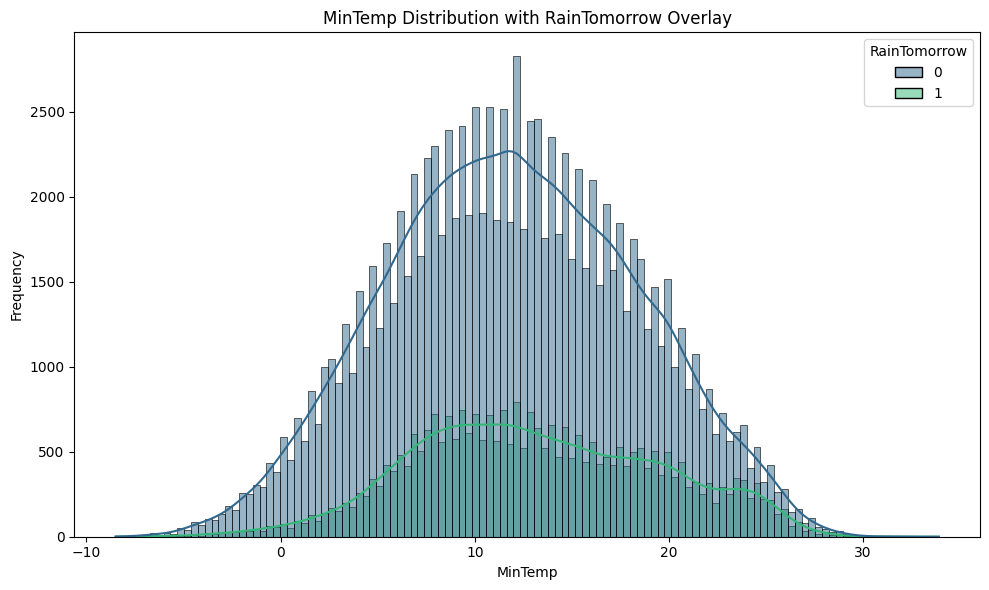

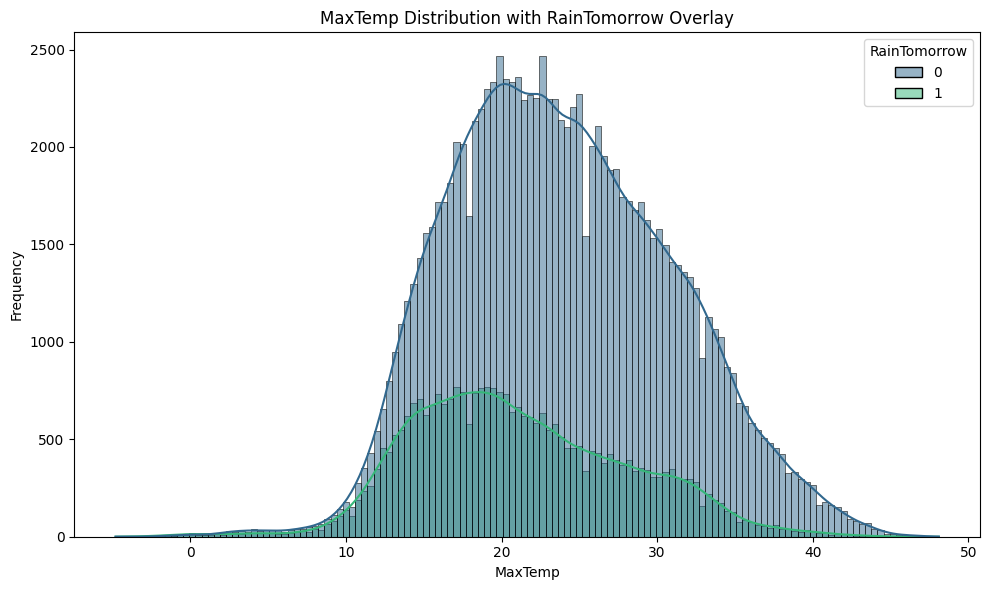

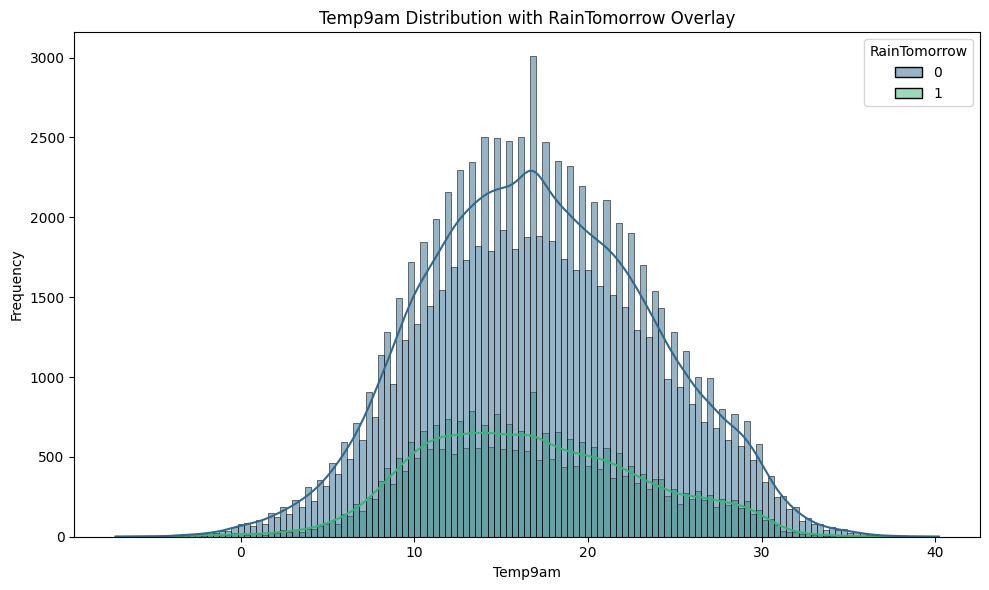

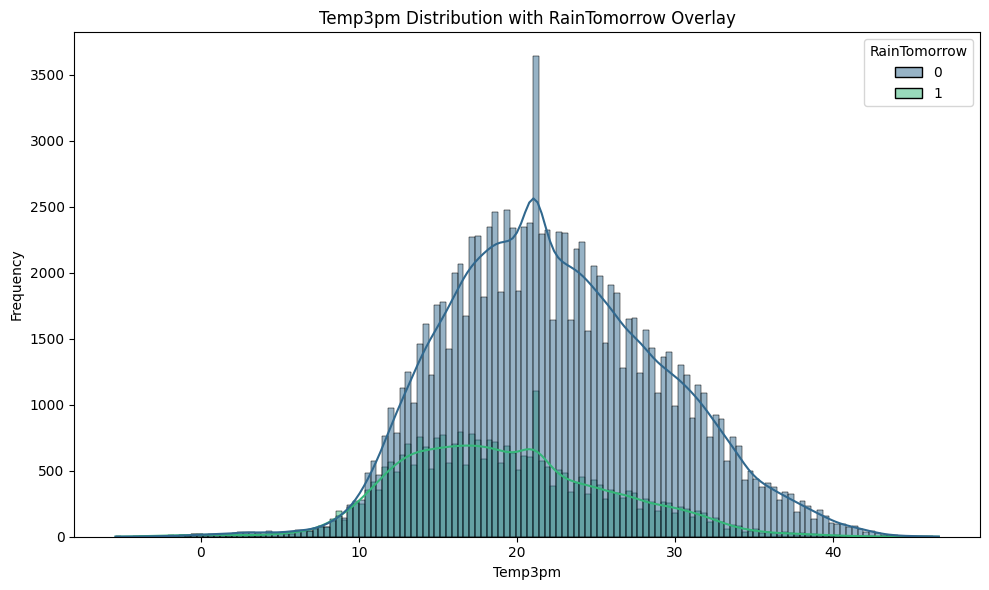

In [220]:
temp_cols = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']

for col in temp_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_copy, x=col, hue='RainTomorrow', palette='viridis', kde=True)
    plt.title(f'{col} Distribution with RainTomorrow Overlay')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()



   

>   MinTemp Distribution with RainTomorrow Overlay

* The x-axis represents the minimum temperature (MinTemp). The y-axis represents the frequency (count) of days within each temperature range.
* The blue bars and line show the distribution of minimum temperatures for days when it did not rain the next day. This distribution appears somewhat bell-shaped, centered around a moderate minimum temperature.
* The green bars and line show the distribution of minimum temperatures for days when it did rain the next day. This distribution seems to be shifted slightly towards lower minimum temperatures compared to the 'No' distribution, although there is a significant overlap.
* In summary, this chart helps visualize if there is a noticeable difference in minimum temperatures on days preceding a rainy day compared to days preceding a non-rainy day.


>   MaxTemp Distribution with RainTomorrow Overlay

* This chart shows the distribution of maximum temperature (MaxTemp) for days when it rained the next day (green) and days when it didn't (blue).
* You can see that the distribution for days with no rain tomorrow is shifted towards higher maximum temperatures compared to the distribution for days with rain tomorrow.
* This suggests that higher maximum temperatures are more common on days preceding a non-rainy day.

>   Temp9am Distribution with RainTomorrow Overlay

* This chart visualizes the distribution of temperature at 9 am (Temp9am), separated by whether it rained the next day ('Yes', green) or not ('No', blue).
* Similar to MinTemp, the distributions largely overlap, but there might be subtle differences in the peaks or spread that indicate a slight tendency for Temp9am to be different on days preceding rain.


>   Temp3pm Distribution with RainTomorrow Overlay

* This chart shows the distribution of temperature at 3 pm (Temp3pm) for days with and without rain expected the next day.
* Similar to MaxTemp, the distribution for days with no rain tomorrow (blue) is shifted towards higher temperatures compared to days with rain tomorrow (green).
* This suggests that higher temperatures in the afternoon are more frequent when rain is not expected the next day.





***Humidity variables (Humidity9am, Humidity3pm) distribution with RainTomorrow***

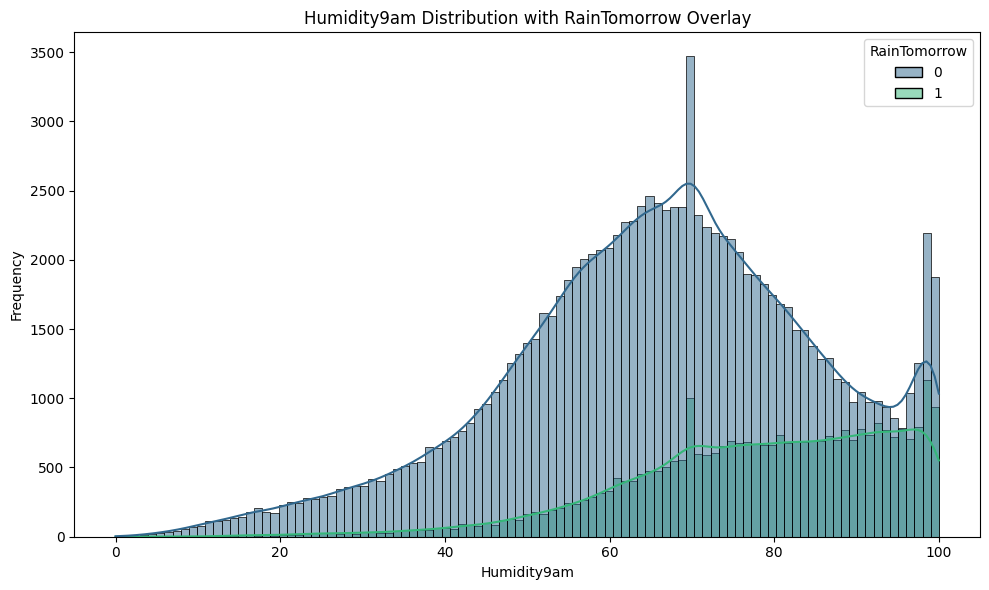

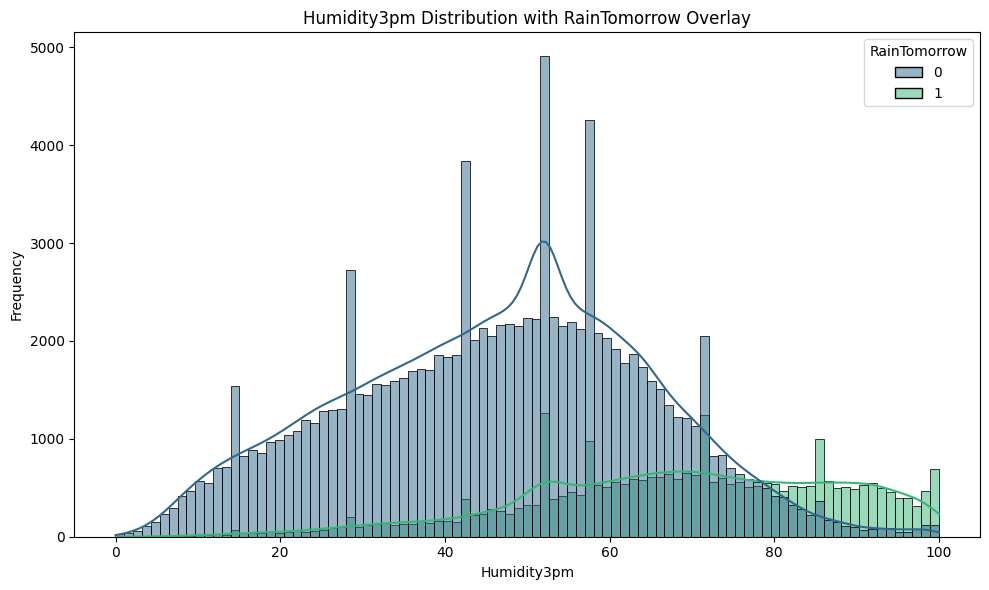

In [221]:
humidity_cols = ['Humidity9am', 'Humidity3pm']

for col in humidity_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_copy, x=col, hue='RainTomorrow', palette='viridis', kde=True)
    plt.title(f'{col} Distribution with RainTomorrow Overlay')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()



>   Humidity9am Distribution with RainTomorrow overlay

* The blue bars and line show the distribution of Humidity9am for days where it was predicted not to rain tomorrow. This distribution has a peak at a moderate humidity level but also shows a significant number of occurrences at lower humidity levels.
* "RainTomorrow: No" (blue) appears to be skewed to the left (negatively skewed). This means that while there's a peak at a moderate humidity level, there's a longer tail extending towards lower humidity values.
* The green bars and line show the distribution of Humidity9am for days where it was predicted to rain tomorrow. This distribution is notably shifted towards higher humidity levels compared to the 'No' distribution and has a peak at a much higher humidity value.
* In summary, both distributions are skewed to the left, but the distribution for days with predicted rain tomorrow is shifted towards higher humidity levels and has less of a tail at the very low end compared to the distribution for days with no predicted rain tomorrow.

>   Humidity3pm Distribution with RainTomorrow overlay

* The blue bars and line show the distribution of Humidity3pm for days where it was predicted not to rain tomorrow. This distribution is spread across a wider range of humidity values, with peaks at lower to moderate humidity levels.
* Blue bars appears to be skewed to the right (positively skewed). This means that while there are peaks at lower to moderate humidity levels, there's a longer tail extending towards higher humidity values.
* The green bars and line show the distribution of Humidity3pm for days where it was predicted to rain tomorrow. This distribution is significantly shifted towards higher humidity levels compared to the 'No' distribution, with a notable peak at higher humidity values and a concentration of data points at the very high end.
* Green bars appears to be skewed to the left (negatively skewed), with a strong concentration at higher humidity levels and a tail extending towards lower humidity values.
* Similar to Humidity9am, this indicates that higher humidity levels at 3 pm are strongly associated with a higher likelihood of rain the next day. The difference in distributions between 'Yes' and 'No' is quite pronounced, making Humidity3pm another potentially important feature for predicting rain tomorrow.



***Pressure9am\Pressure3pm distribution by RainTomorrow***

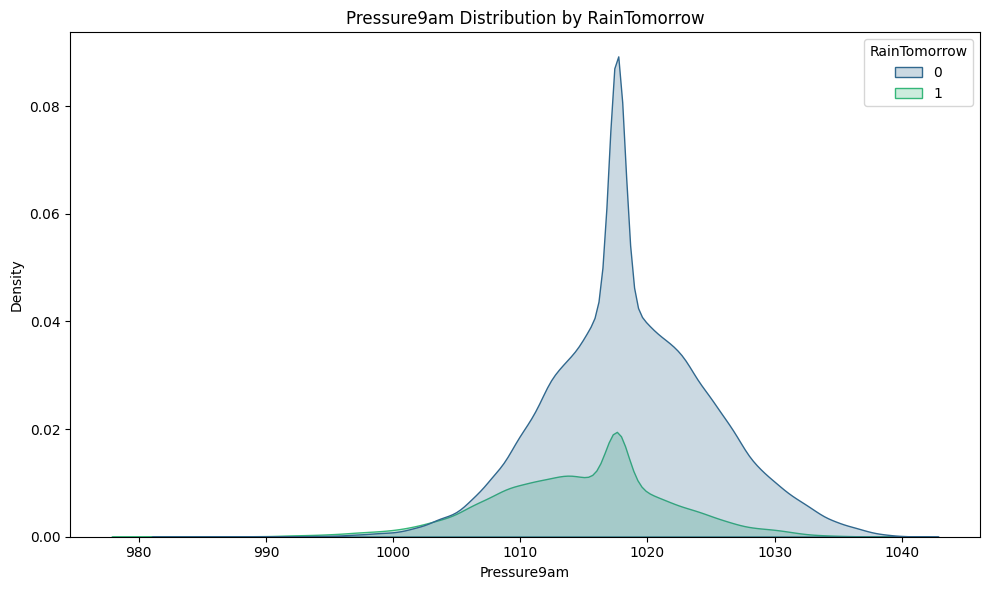

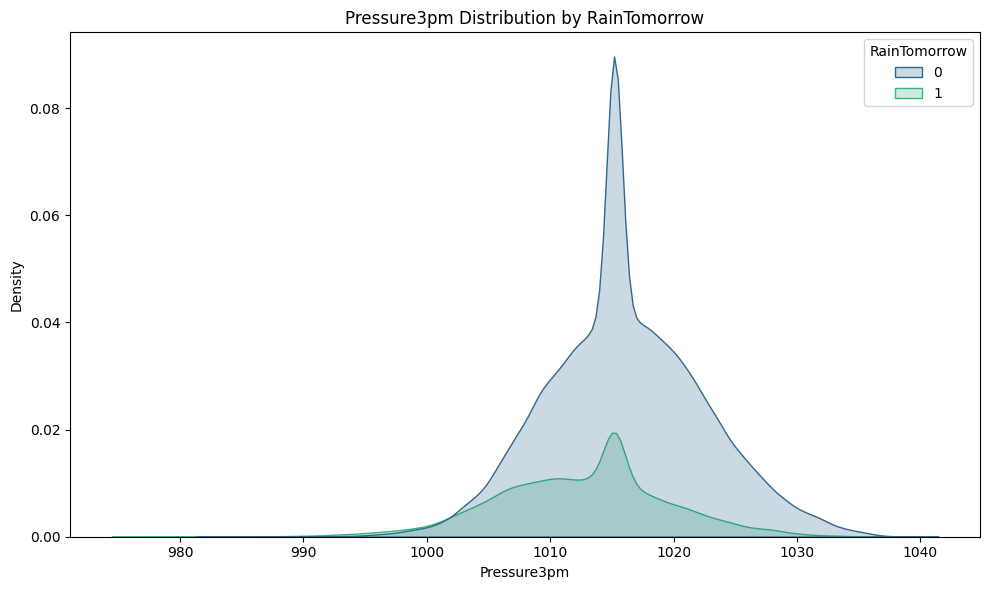

In [222]:
pressure_cols = ['Pressure9am', 'Pressure3pm']

for col in pressure_cols:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df_copy, x=col, hue='RainTomorrow', palette='viridis', fill=True)
    plt.title(f'{col} Distribution by RainTomorrow')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()



>   Pressure9am Distribution by RainTomorrow

* The blue shaded area represents the distribution of Pressure9am for days where it was predicted not to rain tomorrow. This distribution is centered around a higher pressure value and is relatively narrower.
* The green shaded area represents the distribution of Pressure9am for days where it was predicted to rain tomorrow. This distribution is shifted towards lower pressure values compared to the 'No' distribution and appears broader.
* This indicates that lower atmospheric pressure at 9 am is associated with a higher likelihood of rain the next day, while higher pressure is associated with no rain. The distinct separation and difference in shape between the two density curves suggest that Pressure9am is a relevant feature for predicting rain tomorrow.   

>    Pressure3pm Distribution by RainTomorrow

* The blue shaded area represents the distribution of Pressure3pm for days where it was predicted not to rain tomorrow. Similar to Pressure9am, this distribution is centered around a higher pressure value.
* The green shaded area represents the distribution of Pressure3pm for days where it was predicted to rain tomorrow. This distribution is also shifted towards lower pressure values compared to the 'No' distribution.
* Similar to Pressure9am, this indicates that lower atmospheric pressure at 3 pm is associated with a higher likelihood of rain the next day, while higher pressure is associated with no rain. The separation between the two density curves suggests that Pressure3pm is also a relevant feature for predicting rain tomorrow.




***WindGustSpeed Distribution by RainTomorrow***

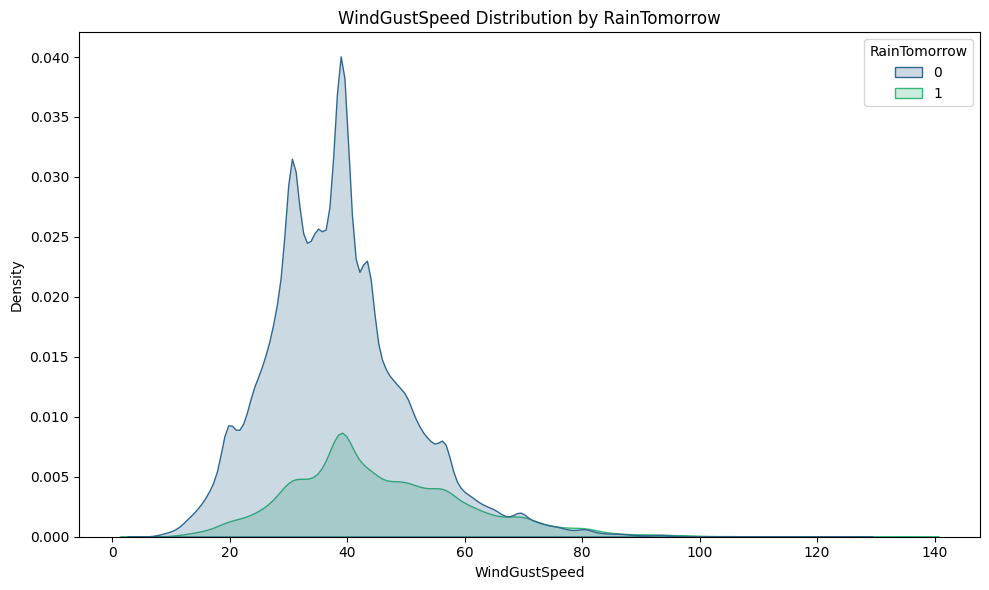

In [223]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_copy, x='WindGustSpeed', hue='RainTomorrow', palette='viridis', fill=True)
plt.title('WindGustSpeed Distribution by RainTomorrow')
plt.xlabel('WindGustSpeed')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

* The blue shaded area represents the distribution of WindGustSpeed for days where it was predicted not to rain tomorrow. This distribution has a peak at a lower wind gust speed and is more concentrated towards lower speeds.

* The green shaded area represents the distribution of WindGustSpeed for days where it was predicted to rain tomorrow. This distribution is shifted towards higher wind gust speeds compared to the 'No' distribution and appears broader with a tail extending to higher speeds.

* This indicates that higher wind gust speeds are associated with a higher likelihood of rain the next day, while lower wind gust speeds are more common on days preceding no rain. The difference in the shape and position of the two density curves suggests that WindGustSpeed is a relevant feature for predicting rain tomorrow.

***Evaporation and Sunshine Distribution by RainTomorrow***

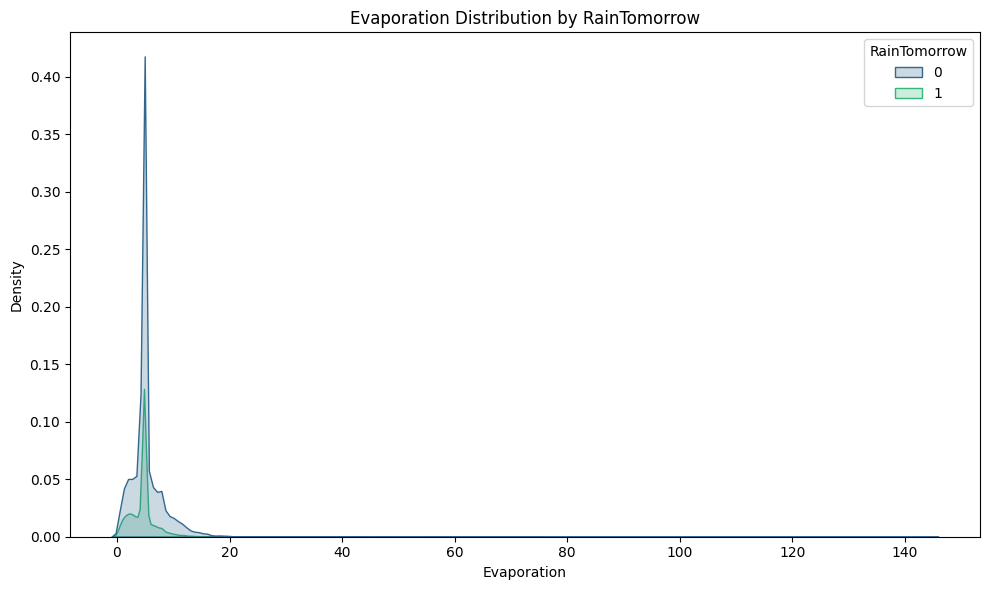

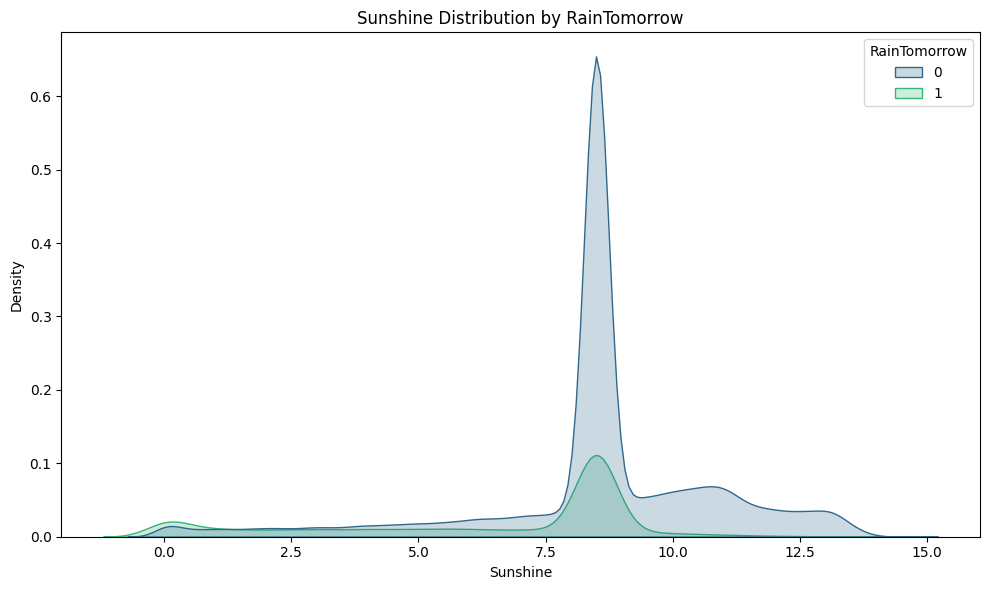

In [224]:
other_cols = ['Evaporation', 'Sunshine']

for col in other_cols:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df_copy, x=col, hue='RainTomorrow', palette='viridis', fill=True)
    plt.title(f'{col} Distribution by RainTomorrow')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()



>   Evaporation Distribution by RainTomorrow

* The blue shaded area represents the distribution of Evaporation for days where it was predicted not to rain tomorrow. This distribution is heavily concentrated at lower evaporation values and quickly drops off as evaporation increases.
* The green shaded area represents the distribution of Evaporation for days where it was predicted to rain tomorrow. This distribution is also concentrated at lower evaporation values, but the density is lower than the 'No' distribution at the very lowest values and extends slightly further out to higher evaporation values.
* This indicates that lower evaporation amounts are more common on days preceding both rain and no rain. However, the distribution for days with no rain tomorrow is even more skewed towards very low evaporation compared to days with rain tomorrow. This suggests that while high evaporation is generally less frequent, it is even less likely to occur on days followed by rain.

>   Sunshine Distribution by RainTomorrow

* The blue shaded area represents the distribution of Sunshine for days where it was predicted not to rain tomorrow. This distribution has a clear peak at a higher number of sunshine hours, indicating that sunny days are more common when rain is not expected the next day. There is also a smaller peak at 0 sunshine hours.
* The green shaded area represents the distribution of Sunshine for days where it was predicted to rain tomorrow. This distribution is shifted towards lower sunshine hours, with a significant concentration at 0 sunshine hours and a rapid decrease in density as sunshine hours increase.
* This indicates that days with more sunshine are strongly associated with no rain the next day, while days with less sunshine (or no sunshine) are more associated with rain the next day. The distinct separation between the two density curves makes Sunshine a potentially very useful feature for predicting rain tomorrow.


## **Outlier Detection & Comparison**

***Box Plots of Temperatures by RainTomorrow***

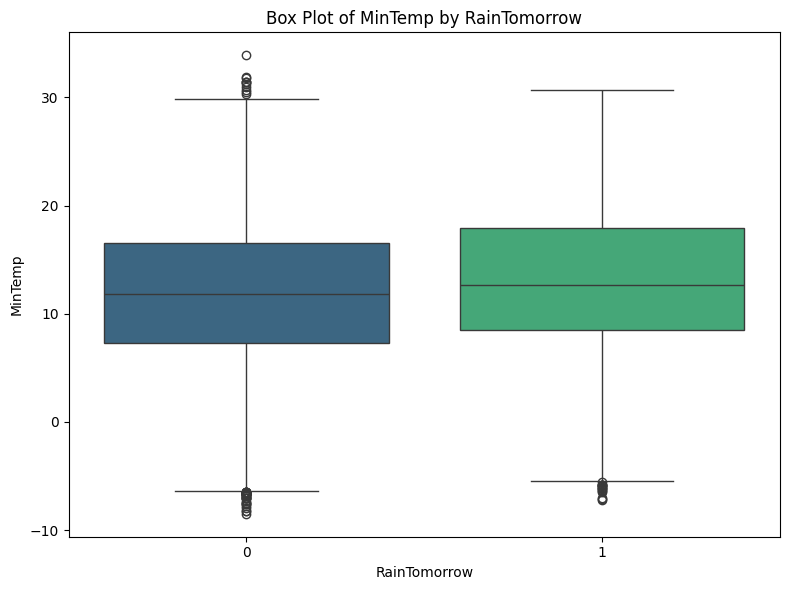

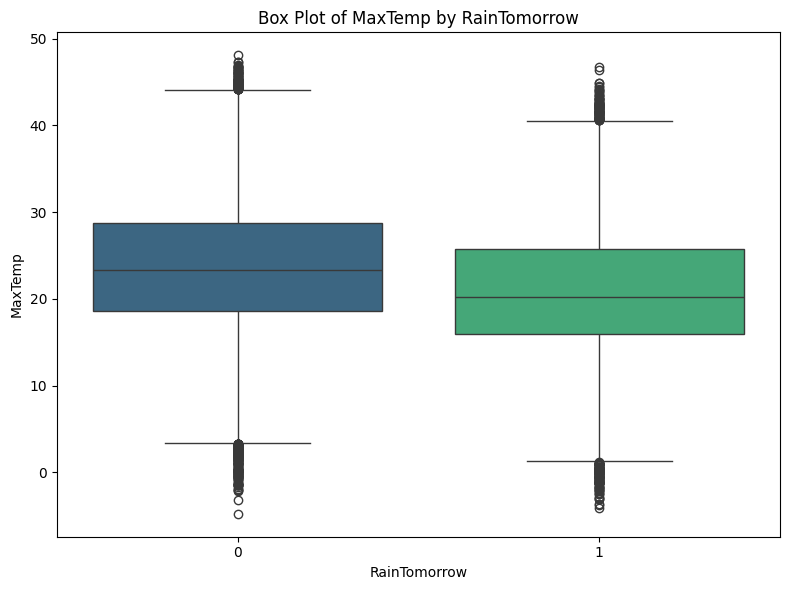

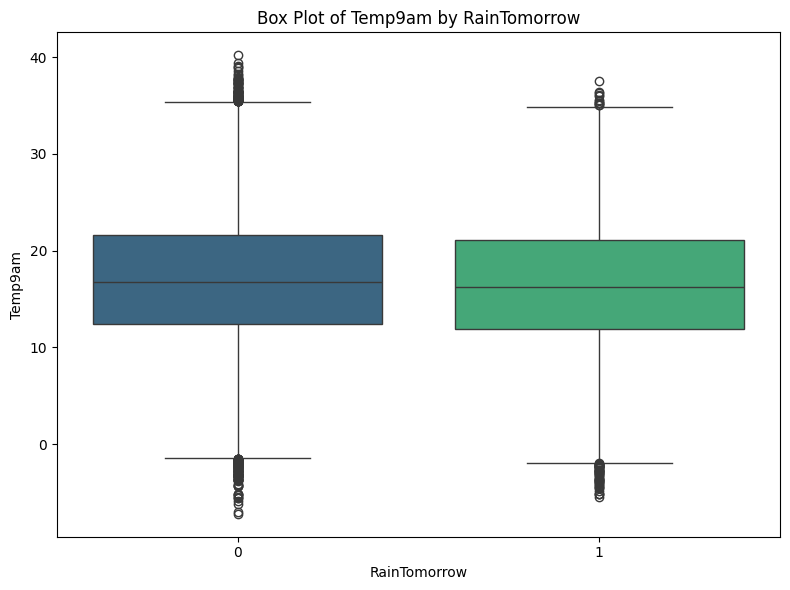

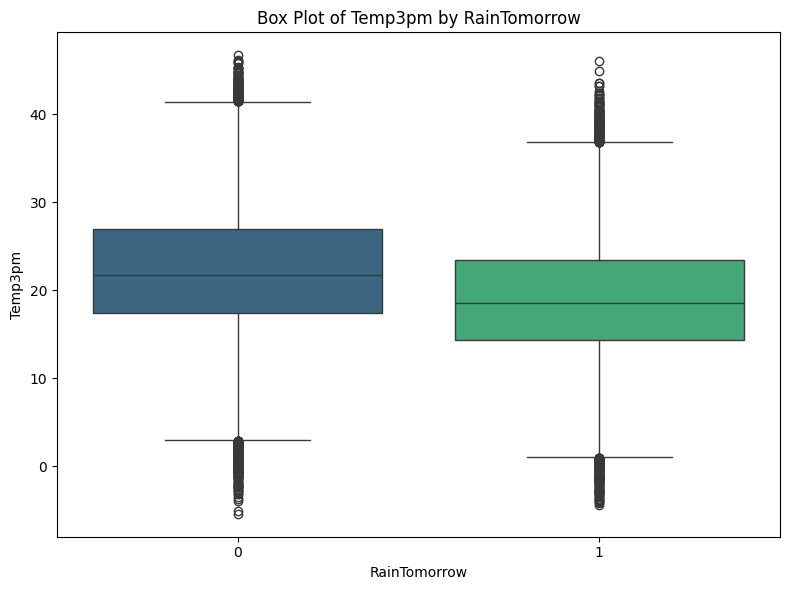

In [225]:
temp_cols = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']

for col in temp_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_copy, x='RainTomorrow', y=col, palette='viridis', hue='RainTomorrow', legend=False)
    plt.title(f'Box Plot of {col} by RainTomorrow')
    plt.xlabel('RainTomorrow')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()



>   Box plot of MinTemp by RainTomorrow

* The median line in the 'Yes' box is slightly higher than the median line in the 'No' box. This suggests that the middle temperature on days before rain is slightly warmer than on days before no rain.
* The box for the 'No' group appears slightly wider than the box for the 'Yes' group. This means the middle 50% of MinTemp values has a slightly larger range on days before no rain.  
* Both groups exhibit outliers. This means that, regardless of whether rain was expected tomorrow, there were days with exceptionally low or high minimum temperatures    

>   Box plot of MaxTemp by RainTomorrow

* The median line in the 'No' box is significantly higher than the median line in the 'Yes' box. This suggests that the middle maximum temperature on days before no rain is considerably warmer than on days before rain.
* For the 'No' RainTomorrow (blue box), there are noticeable outliers on both the low and high ends. However, there appear to be more outliers, and potentially outliers with higher values, on the upper end. These represent days with unusually high maximum temperatures when rain was not expected the next day.
* For the 'Yes' RainTomorrow (green box), there are also outliers on both the low and high ends, but they seem less numerous and less extreme on the high end compared to the 'No' group. These represent unusually high or low maximum temperatures when rain was expected the next day.

>   Box plot of Temp3pm by RainTomorrow

* The median line in the 'No' box appears slightly higher than the median line in the 'Yes' box. This suggests that the middle temperature at 9 am on days before no rain is slightly warmer than on days before rain.
* Both the 'No' and 'Yes' groups show outliers on both the lower and upper ends. There don't appear to be significantly more outliers on one side for either group compared to the other, although there are some extreme values present in both scenarios.

>   Box plot of Temp3pm by RainTomorrow

* The median Temp3pm for the 'No' (no rain tomorrow) group is noticeably higher than the median Temp3pm for the 'Yes' (rain tomorrow) group. This suggests that on average, temperatures in the afternoon are warmer on days preceding no rain compared to days preceding rain.
* Both the 'No' and 'Yes' groups show outliers on both the lower and upper ends.
* The concentration of upper outliers in the 'No' group reinforces that very high afternoon temperatures are more likely when rain is not expected the following day.


***Box Plots of Humidity by RainTomorrow***

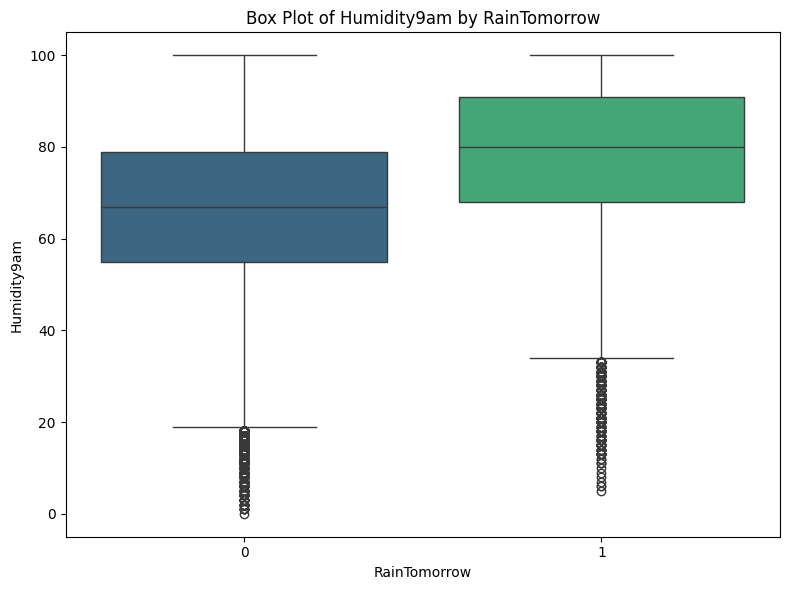

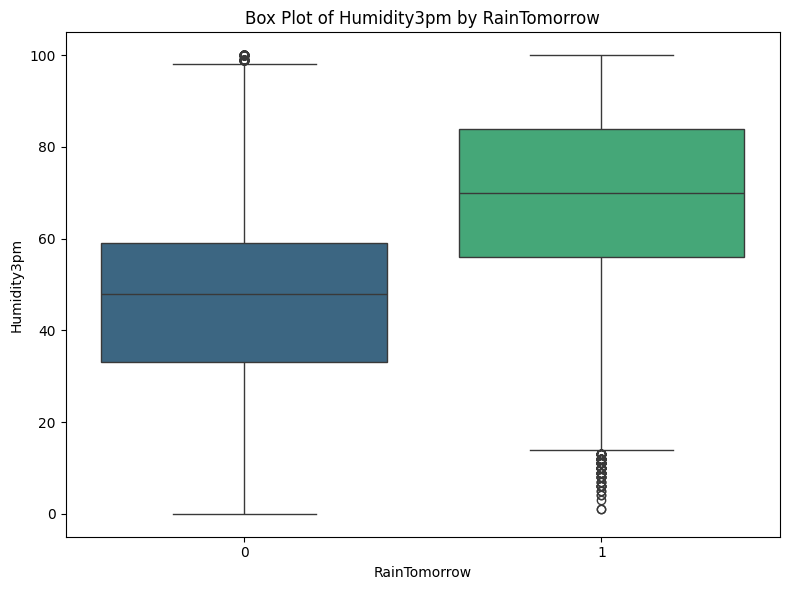

In [226]:
humidity_cols = ['Humidity9am', 'Humidity3pm']

for col in humidity_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_copy, x='RainTomorrow', y=col, palette='viridis', hue='RainTomorrow', legend=False)
    plt.title(f'Box Plot of {col} by RainTomorrow')
    plt.xlabel('RainTomorrow')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()



>   Box Plot of Humidity9am by RainTomorrow

* The median line in the 'Yes' box is significantly higher than the median line in the 'No' box. This indicates that the middle Humidity9am level is considerably higher on days preceding rain compared to days preceding no rain. This is a strong indicator of the relationship between higher morning humidity and the likelihood of rain the next day.
* Both the 'No' and 'Yes' groups show outliers primarily at the lower end of the humidity scale. These represent days with unusually low humidity at 9 am for both categories.


>   Box Plot of Humidity3pm by RainTomorrow

* The median line in the 'Yes' box is significantly higher than the median line in the 'No' box. This indicates that the middle Humidity3pm level is considerably higher on days preceding rain compared to days preceding no rain. This is a strong indicator that higher humidity in the afternoon is associated with rain the next day.
* Both the 'No' and 'Yes' groups show outliers. The 'No' group has outliers primarily at the very high end of the humidity scale, representing unusually high afternoon humidity on days preceding no rain. The 'Yes' group has outliers primarily at the very low end, representing unusually low afternoon humidity on days preceding rain.



***Box Plots of Wind by RainTomorro***



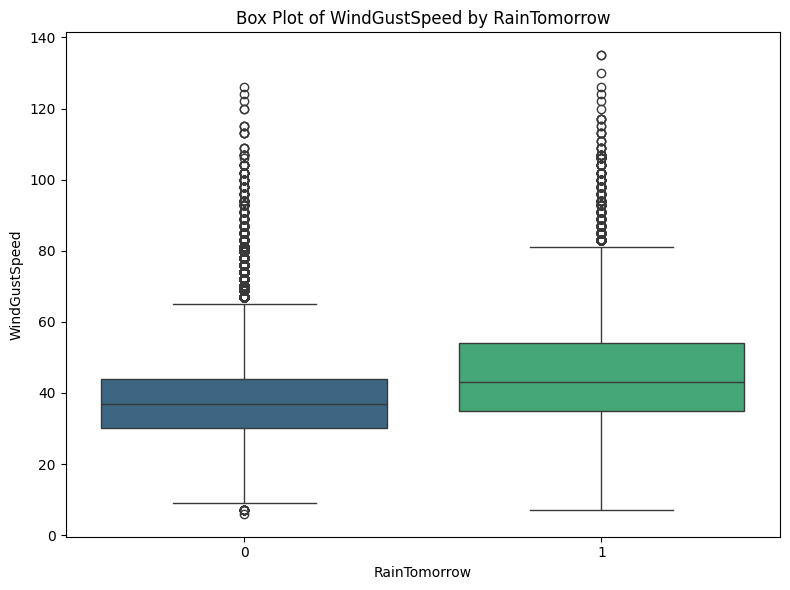

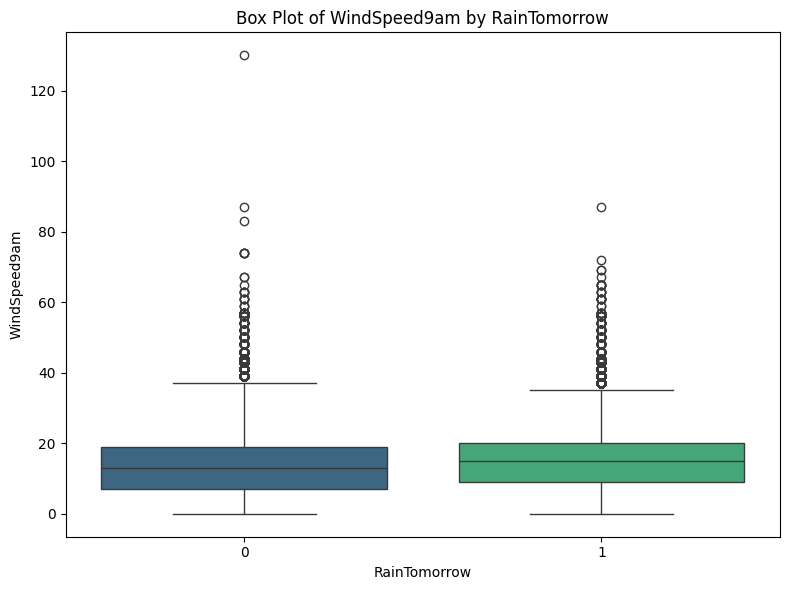

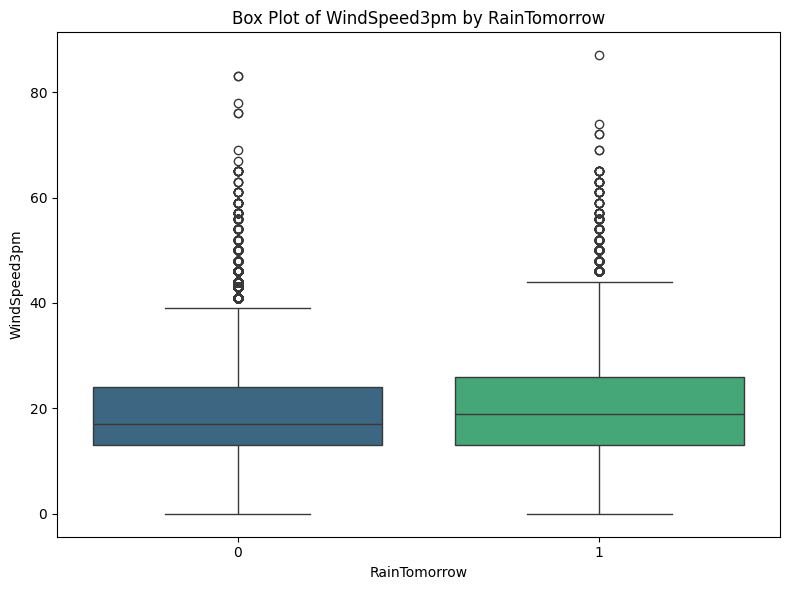

In [227]:
wind_cols = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']

for col in wind_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_copy, x='RainTomorrow', y=col, palette='viridis', hue='RainTomorrow', legend=False)
    plt.title(f'Box Plot of {col} by RainTomorrow')
    plt.xlabel('RainTomorrow')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()



>   Box Plot of WindGuestSpeed by RainTomorrow

* The median line in the 'Yes' box (rain tomorrow, green) appears noticeably higher than the median line in the 'No' box (no rain tomorrow, blue). This suggests that the middle value for wind gust speed is higher on days when rain is expected the next day compared to days when it's not.
* Both the 'No' and 'Yes' groups show a significant number of individual data points (outliers) plotted above their upper whiskers. These represent instances of unusually high wind gust speeds. There appear to be more high outliers, and potentially outliers with higher values, in the 'Yes' group. This indicates that very strong wind gusts are more frequent on days preceding rain tomorrow. There are also some outliers at the very low end for the 'No' group, representing unusually low wind gust speeds.

>   Box Plot of WindSpeed9am by RainTomorrow

* The median line in the 'Yes' box (rain tomorrow, green) appears slightly higher than the median line in the 'No' box (no rain tomorrow, blue). This suggests that the middle value for wind speed at 9 am is slightly higher on days when rain is expected the next day compared to days when it's not.
* Both the 'No' and 'Yes' groups show a significant number of individual data points (outliers) plotted above their upper whiskers. These represent instances of unusually high wind speeds at 9 am. There appear to be a comparable number of high outliers in both the 'No' and 'Yes' groups, with some very extreme values present in both.


>   Box Plot of WindSpeed3m by RainTomorrow

* The median line in the 'Yes' box (rain tomorrow, green) appears noticeably higher than the median line in the 'No' box (no rain tomorrow, blue). This suggests that the middle value for wind speed at 3 pm is higher on days when rain is expected the next day compared to days when it's not.
* Both the 'No' and 'Yes' groups show a significant number of individual data points (outliers) plotted above their upper whiskers. These represent instances of unusually high wind speeds at 3 pm. There appear to be a comparable number of high outliers in both the 'No' and 'Yes' groups, with some very extreme values present in both.


***Box Plots of Atmospheric Features by RainTomorrow***

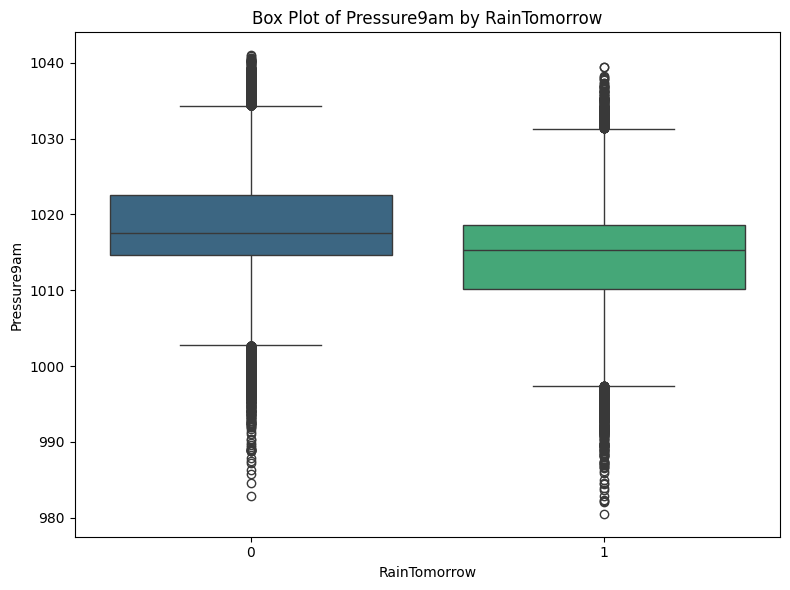

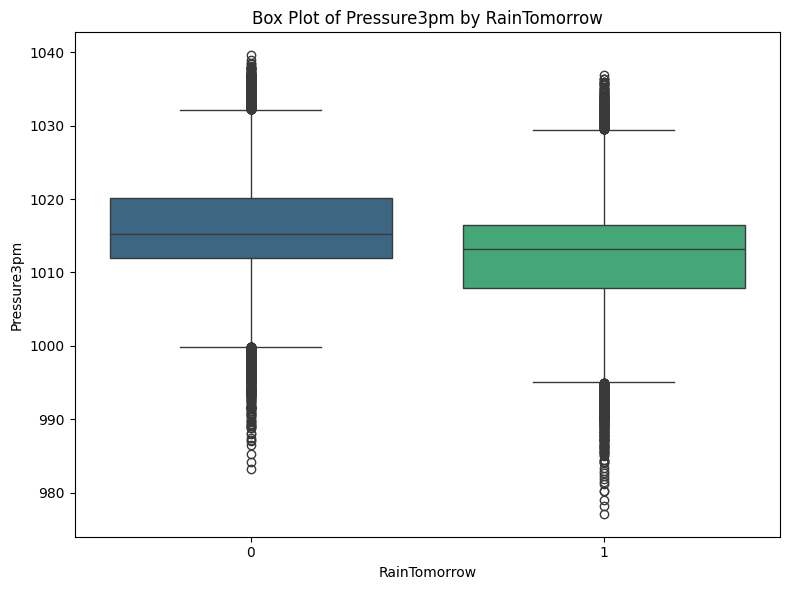

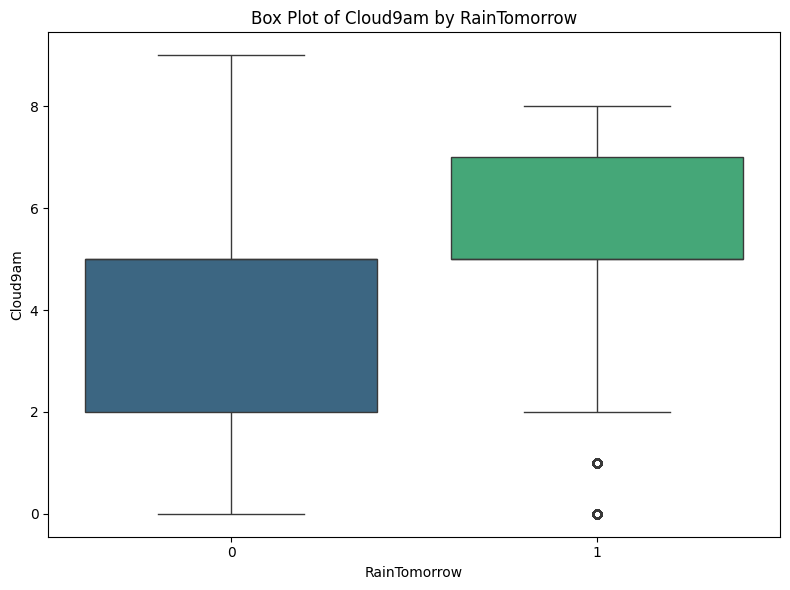

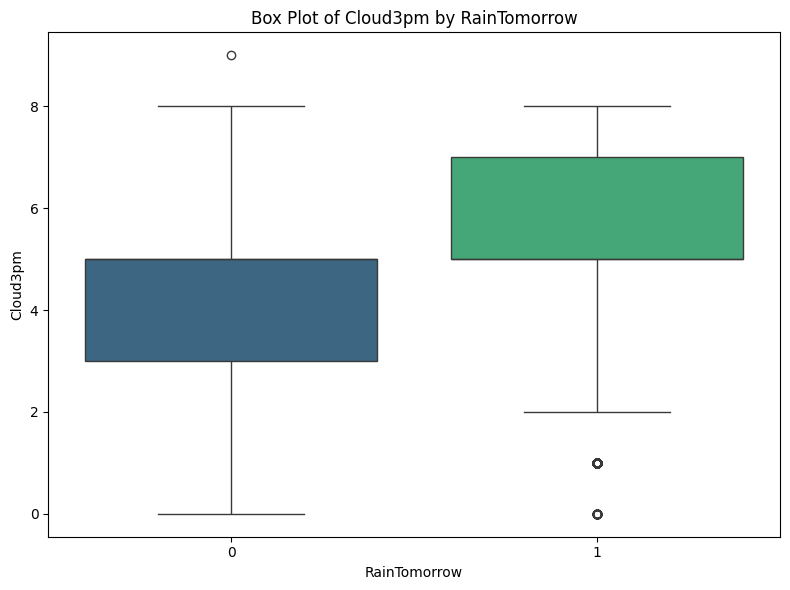

In [228]:
atmospheric_cols = ['Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm']

for col in atmospheric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_copy, x='RainTomorrow', y=col, palette='viridis', hue='RainTomorrow', legend=False)
    plt.title(f'Box Plot of {col} by RainTomorrow')
    plt.xlabel('RainTomorrow')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()



>   Box Plot of Pressure9am by  RainTomorrow

* The median line in the 'No' box (no rain tomorrow, blue) is noticeably higher than the median line in the 'Yes' box (rain tomorrow, green). This suggests that the middle value for pressure at 9 am is higher on days when rain is not expected the next day compared to days when it is.
* Both the 'No' and 'Yes' groups show a significant number of individual data points (outliers) plotted both below the lower whisker and above the upper whisker. These represent instances of unusually low or high pressure at 9 am. There appear to be outliers on both ends for both groups, indicating that extreme pressure values occurred regardless of whether it rained the next day.


>   Box Plot of Pressure3pm by  RainTomorrow

* The median line in the 'No' box (no rain tomorrow, blue) is noticeably higher than the median line in the 'Yes' box (rain tomorrow, green). This suggests that the middle value for pressure at 3 pm is higher on days when rain is not expected the next day compared to days when it is. Similar to Pressure9am, lower pressure at 3 pm is associated with rain the next day.
* Both the 'No' and 'Yes' groups show a significant number of individual data points (outliers) plotted both below the lower whisker and above the upper whisker. These represent instances of unusually low or high pressure at 3 pm. There appear to be outliers on both ends for both groups, indicating that extreme pressure values occurred regardless of whether it rained the next day.


>   Box Plot of Cloud9am by  RainTomorrow

* The 'No' group (blue box) shows no outliers. The 'Yes' group (green box) shows some outliers at the lower end of cloud cover (values near 0 and 1).
    



>   Box Plot of Cloud3pm by  RainTomorrow

* The 'No' group (blue box) shows outliers primarily at the higher end of cloud cover (values near 9). The 'Yes' group (green box) shows some outliers at the lower end of cloud cover (values near 0 and 1).


## **Relationships Between Variables**

***Humidity9am vs Humidity3pm***

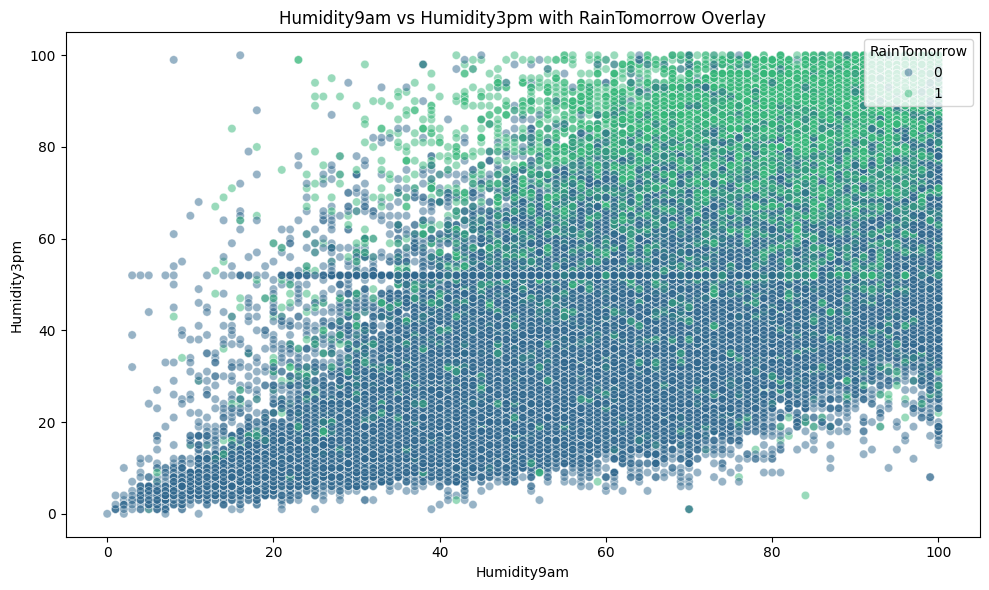

In [229]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='Humidity9am', y='Humidity3pm', hue='RainTomorrow', palette='viridis', alpha=0.5)
plt.title('Humidity9am vs Humidity3pm with RainTomorrow Overlay')
plt.xlabel('Humidity9am')
plt.ylabel('Humidity3pm')
plt.legend(title='RainTomorrow', loc='upper right')  # Specify legend location
plt.tight_layout()
plt.show()

* There seems to be a general trend where higher humidity in the morning is associated with higher humidity in the afternoon, and vice versa. The points are clustered in a way that suggests a positive correlation, although there's significant spread.

* The points are clearly separated based on the RainTomorrow variable:
  * The blue points (representing 'No' rain tomorrow) are more spread out across the plot, but tend to be concentrated in areas where both 9 am and 3 pm humidity are lower.
  * The green points (representing 'Yes' rain tomorrow) are more concentrated in the upper right portion of the plot, indicating higher humidity levels at both 9 am and 3 pm.

* The distinct clustering of the 'Yes' points in the high-humidity region suggests that high humidity throughout the day is a strong indicator of rain the next day. While there is some overlap between the blue and green points, particularly at moderate humidity levels, the separation at the extremes indicates that humidity is a very relevant feature for predicting rain tomorrow.

* In summary, the chart visually confirms that higher humidity, both in the morning and afternoon, is strongly associated with a higher likelihood of rain the following day.

***Pressure9am vs Pressure3pm***

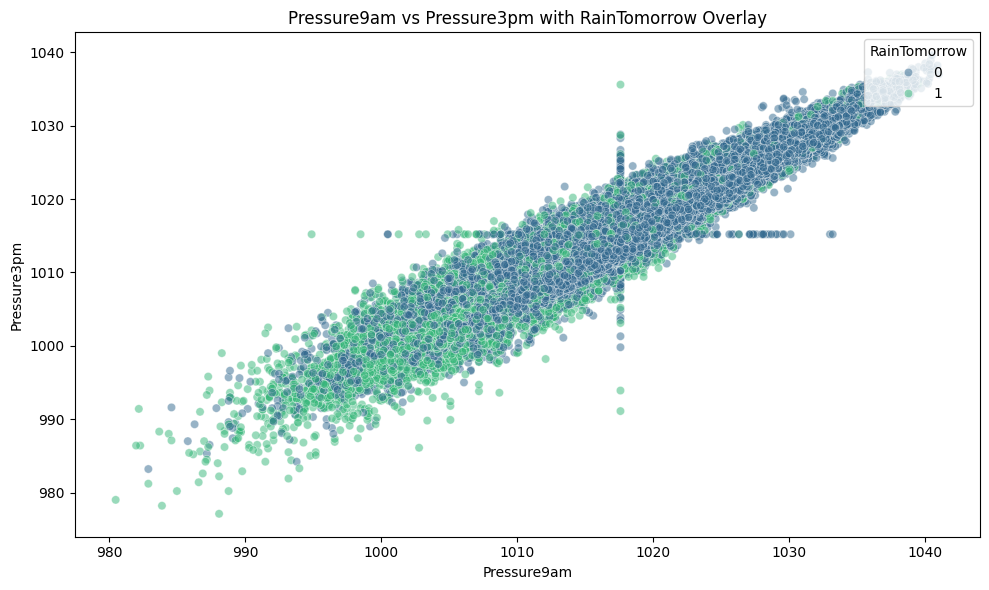

In [230]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='Pressure9am', y='Pressure3pm', hue='RainTomorrow', palette='viridis', alpha=0.5)
plt.title('Pressure9am vs Pressure3pm with RainTomorrow Overlay')
plt.xlabel('Pressure9am')
plt.ylabel('Pressure3pm')
plt.legend(title='RainTomorrow', loc='upper right')
plt.tight_layout()
plt.show()

* There's a strong positive correlation between Pressure9am and Pressure3pm. The points form a clear cluster along a diagonal line, indicating that generally, if the pressure is high in the morning, it's also high in the afternoon, and vice versa.

*  The points are somewhat separated based on the RainTomorrow variable:

    * The blue points (representing 'No' rain tomorrow) are predominantly clustered in the area of higher pressure values for both 9 am and 3 pm.
    * The green points (representing 'Yes' rain tomorrow) are more concentrated in the area of lower pressure values for both 9 am and 3 pm.

* The separation suggests that lower atmospheric pressure throughout the day is associated with a higher likelihood of rain the next day, while higher pressure is associated with no rain. While there is some overlap between the blue and green points, particularly in the middle range of pressure values, the tendency for 'Yes' to be in lower pressure areas and 'No' to be in higher pressure areas indicates that both Pressure9am and Pressure3pm are relevant features for predicting rain tomorrow.

* In summary, the chart indicates that while there is a strong correlation between morning and afternoon pressure, lower pressure values are more indicative of rain the following day.

***MinTemp vs MaxTemp***

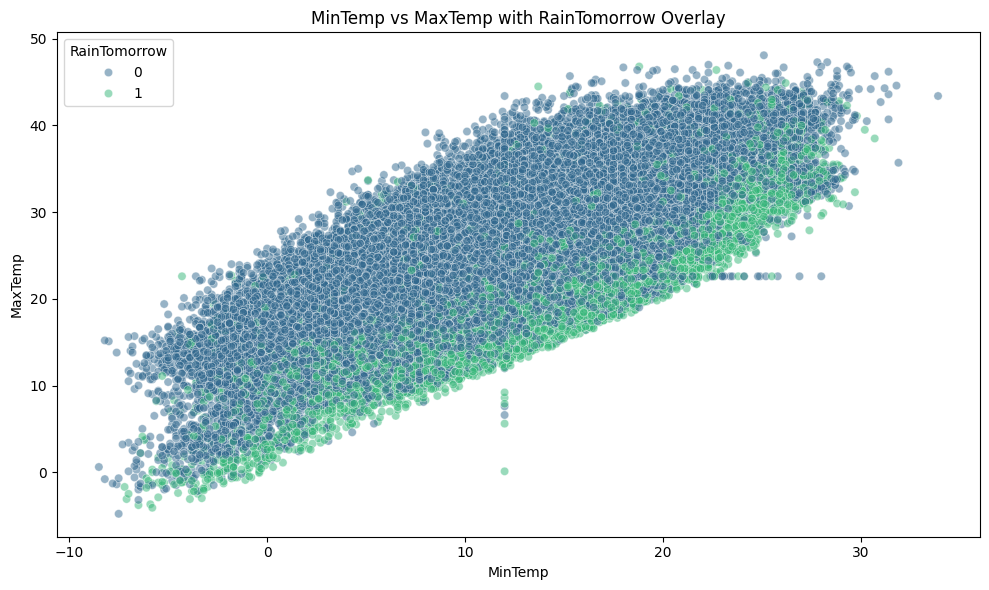

In [231]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='MinTemp', y='MaxTemp', hue='RainTomorrow', palette='viridis', alpha=0.5)
plt.title('MinTemp vs MaxTemp with RainTomorrow Overlay')
plt.xlabel('MinTemp')
plt.ylabel('MaxTemp')
plt.legend(title='RainTomorrow', loc='upper left')
plt.tight_layout()
plt.show()

* There is a strong positive correlation between MinTemp and MaxTemp. As expected, days with higher minimum temperatures tend to have higher maximum temperatures, and vice versa. The points form a clear cluster along a diagonal line.

* While there is a lot of overlap between the blue ('No' rain tomorrow) and green ('Yes' rain tomorrow) points, there are some subtle differences:

    * The blue points (representing 'No' rain tomorrow) are spread across the entire range of temperatures, but seem to be more concentrated in the areas of higher maximum temperatures.
    * The green points (representing 'Yes' rain tomorrow) are also spread across the temperature range, but appear slightly more concentrated in the areas of lower maximum temperatures for a given minimum temperature.

* Compared to the humidity and pressure plots, the separation between the 'Yes' and 'No' points is less distinct in this temperature plot. This suggests that while minimum and maximum temperatures are related, they might not be as strong predictors of rain tomorrow on their own compared to humidity or pressure. However, there is a slight tendency for days with lower maximum temperatures to be followed by rain.

* In summary, the chart shows a strong positive correlation between minimum and maximum temperatures. While there's overlap in the temperature ranges for days with and without predicted rain, there's a subtle indication that days with lower maximum temperatures might be slightly more likely to be followed by rain.

***Rainfall vs Humidity3pm***

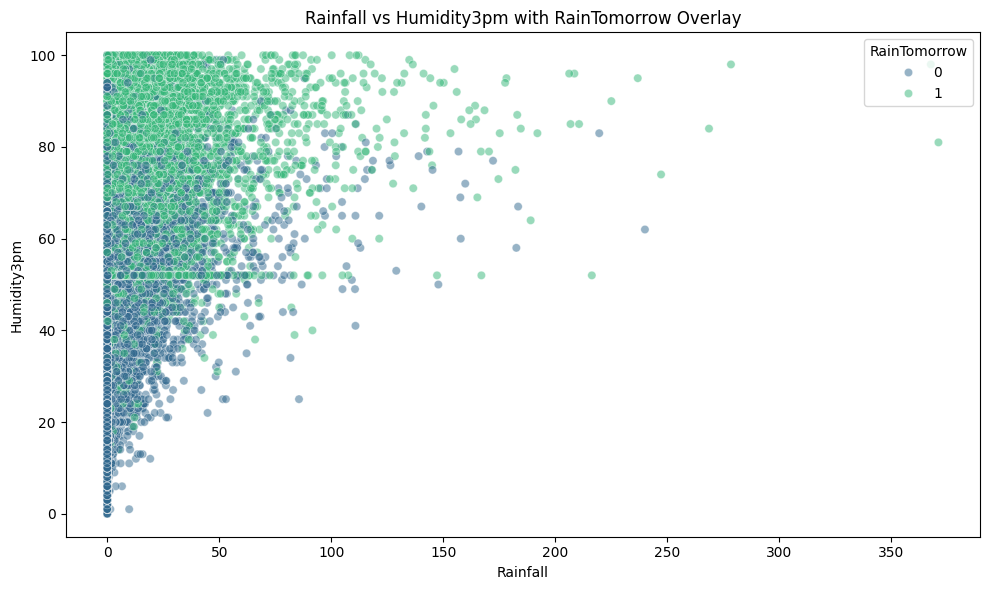

In [232]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='Rainfall', y='Humidity3pm', hue='RainTomorrow', palette='viridis', alpha=0.5)
plt.title('Rainfall vs Humidity3pm with RainTomorrow Overlay')
plt.xlabel('Rainfall')
plt.ylabel('Humidity3pm')
plt.legend(title='RainTomorrow', loc='upper right')
plt.tight_layout()
plt.show()

* There appears to be a weak positive correlation between Rainfall and Humidity3pm, meaning that higher rainfall amounts are somewhat associated with higher humidity at 3 pm, but the relationship is not very strong and there's a lot of scatter.

* The chart highlights that while current rainfall is a factor, high humidity at 3 pm appears to be a stronger indicator of rain the next day, especially when considering higher rainfall amounts. Days with significant rainfall today and high humidity at 3 pm are more likely to be followed by rain. However, there's still overlap, particularly at lower rainfall amounts, meaning neither variable alone is a perfect predictor.

* In summary, the chart suggests that high humidity at 3 pm is a more significant indicator of rain the next day than the amount of rainfall today, although a combination of both might provide better predictive power.

***Cloud3pm vs Sunshine***

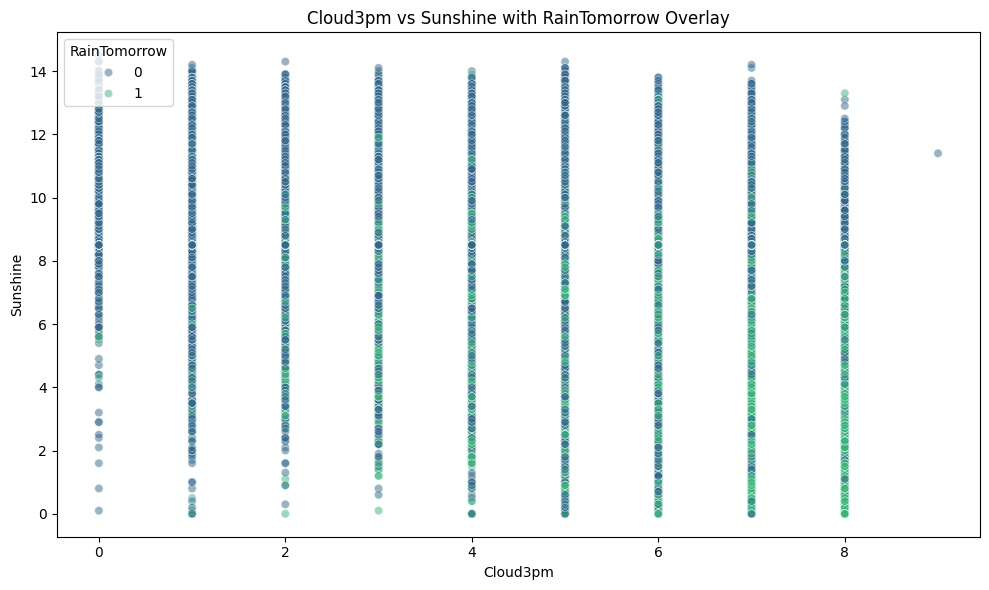

In [233]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='Cloud3pm', y='Sunshine', hue='RainTomorrow', palette='viridis', alpha=0.5)
plt.title('Cloud3pm vs Sunshine with RainTomorrow Overlay')
plt.xlabel('Cloud3pm')
plt.ylabel('Sunshine')
plt.legend(title='RainTomorrow', loc='upper left')
plt.tight_layout()
plt.show()

* This scatter plot reveals a strong inverse relationship between afternoon cloud cover (3pm) and sunshine hours, with distinct patterns based on rain forecasts. The data forms clear vertical bands at discrete cloud cover values (0-8 scale), showing that as cloud cover increases, maximum sunshine hours decrease proportionally - from around 14+ hours with clear skies (0 cloud cover) to near 0 hours with complete cloud cover (8).

* The color coding shows that days forecasted for rain (green/teal points) are predominantly clustered in the higher cloud cover ranges (5-8) with correspondingly lower sunshine hours, while no-rain days (blue points) are more evenly distributed across all cloud cover levels but dominate the lower cloud cover, higher sunshine regions.

* This visualization effectively demonstrates how afternoon cloud conditions strongly predict both sunshine duration and rain probability, with the discrete banding suggesting cloud cover is measured on a standardized meteorological scale rather than as a continuous variable.

***WindGustSpeed vs Rainfall***

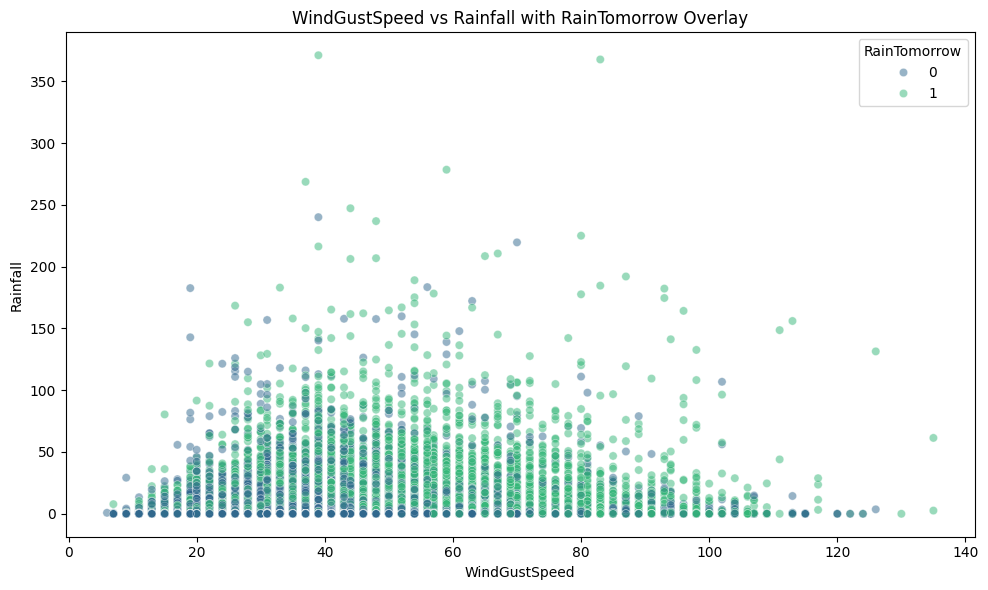

In [234]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='WindGustSpeed', y='Rainfall', hue='RainTomorrow', palette='viridis', alpha=0.5)
plt.title('WindGustSpeed vs Rainfall with RainTomorrow Overlay')
plt.xlabel('WindGustSpeed')
plt.ylabel('Rainfall')
plt.legend(title='RainTomorrow', loc='upper right')
plt.tight_layout()
plt.show()

* This scatter plot shows the relationship between wind gust speed and rainfall, with points colored by rain forecast for tomorrow.

* The data reveals that most observations cluster in the lower rainfall range (0-100mm) across all wind speeds, with both rain and no-rain days well-mixed throughout this region. However, the highest rainfall events (above 200mm) are exclusively associated with days forecasted to have rain tomorrow (green points), and these extreme rainfall events tend to occur with moderate wind gust speeds (20-80 km/h) rather than the highest wind speeds. Interestingly, very high wind gusts (above 100 km/h) are relatively rare and don't necessarily correspond to the heaviest rainfall, suggesting that extreme precipitation events are more associated with sustained weather systems rather than just high wind conditions.

* The overall pattern indicates that while wind gust speed alone isn't a strong predictor of rain occurrence, the combination of moderate-to-high winds with substantial rainfall strongly indicates continued wet weather into the following day.

## **Time-Based Patterns**

***Day of month vs Rainfall***

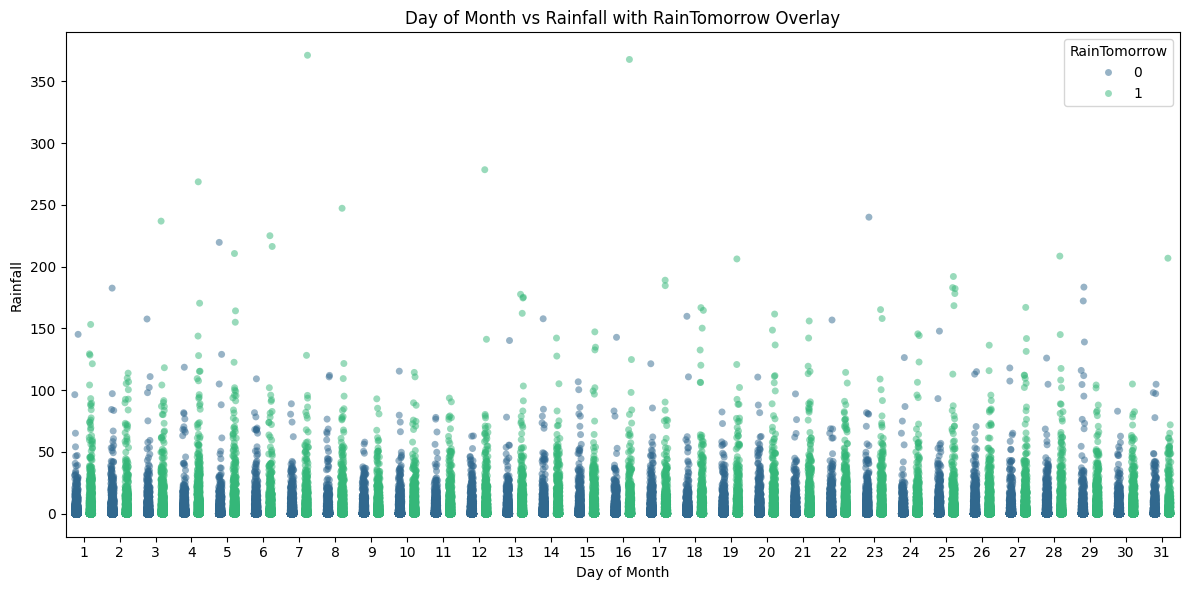

In [394]:
plt.figure(figsize=(12, 6))
sns.stripplot(data=df_copy, x='Day', y='Rainfall', hue='RainTomorrow', palette='viridis', dodge=True, alpha=0.5)
plt.title('Day of Month vs Rainfall with RainTomorrow Overlay')
plt.xlabel('Day of Month')
plt.ylabel('Rainfall')
plt.legend(title='RainTomorrow', loc='upper right')
plt.tight_layout()
plt.show()

* This strip plot displays rainfall amounts across different days of the month (1-12 shown), with points colored to indicate whether rain is forecasted for the following day. The data shows no apparent systematic relationship between the day of the month and rainfall patterns, which is expected since weather patterns operate on different temporal scales than calendar dates. Each day shows a similar distribution of rainfall amounts, with most observations clustered near zero and occasional extreme events reaching up to 370mm, suggesting that rainfall is essentially random with respect to the day of the month.

* The color overlay reveals that days with higher current rainfall (particularly above 100mm) are predominantly associated with rain forecasts for tomorrow (green points), while days with little to no rainfall show a more even mix of rain and no-rain forecasts for the following day.

* This pattern is consistent across all days of the month, reinforcing that current weather conditions are better predictors of tomorrow's weather than calendar positioning. The vertical clustering of points at each day creates clear columns that demonstrate the random nature of when heavy rainfall events occur within a month, with no particular days showing higher propensity for extreme weather events.

## **Correlation Analysis**

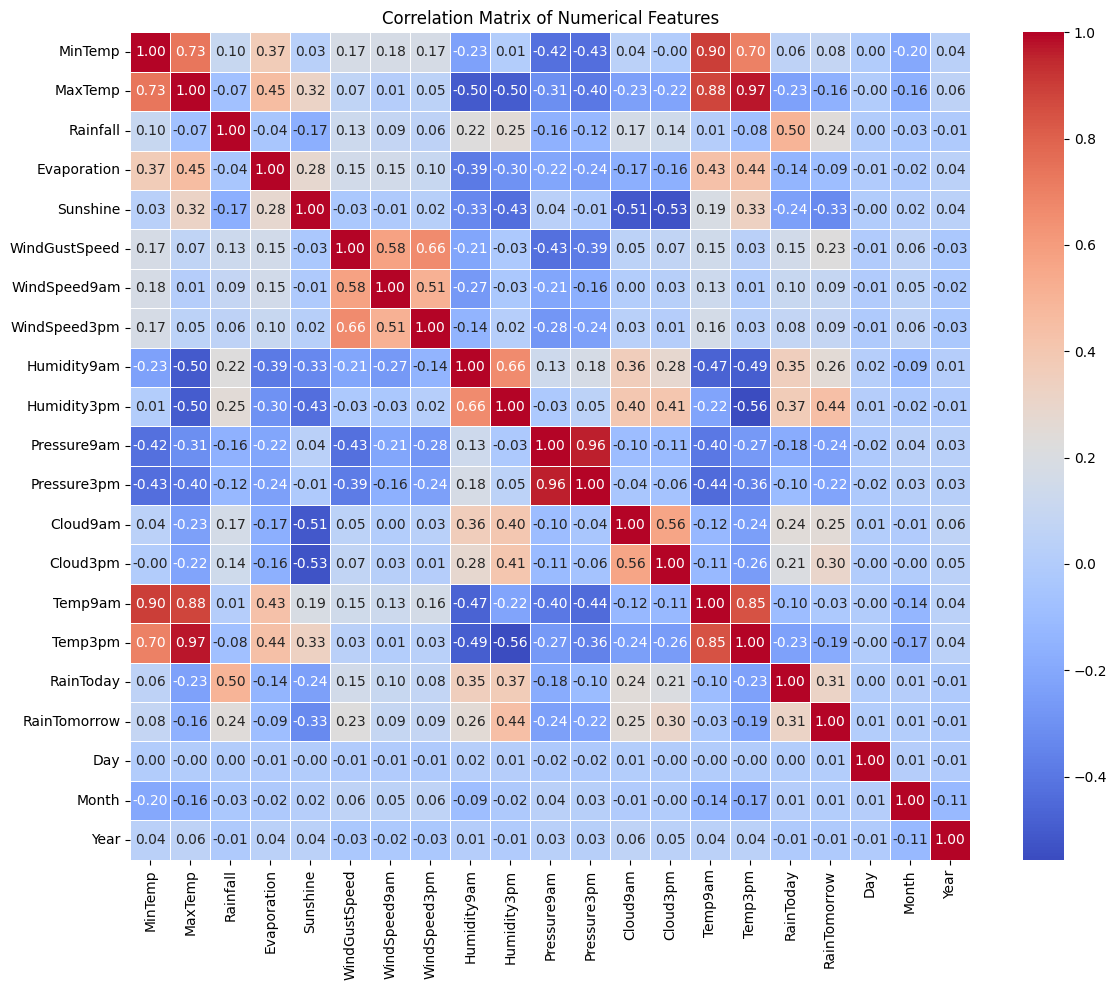

In [395]:
# Select only numerical columns
numerical_df = df_copy.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

> Strongest Positive Correlations (>0.8):

* Temp3pm & MaxTemp (0.97): Nearly perfect - afternoon temperature closely matches daily maximum
* Pressure9am & Pressure3pm (0.96): Atmospheric pressure remains very stable throughout the day
* Temp9am & MinTemp (0.90): Morning temperature strongly reflects daily minimum
* Temp9am & MaxTemp (0.88): Morning temperature predicts afternoon highs well

>Strong Positive Correlations (0.6-0.8):

* MinTemp & MaxTemp (0.73): Daily temperature range consistency
* Temp9am & Temp3pm (0.85): Temperature persistence through the day
* MinTemp & Temp3pm (0.70): Morning lows influence afternoon temperatures
* Humidity9am & Humidity3pm (0.66): Humidity levels remain relatively consistent
* WindGustSpeed & WindSpeed3pm (0.66): Peak gusts correlate with afternoon wind speeds

>Moderate Positive Correlations (0.4-0.6):

* WindSpeed9am & WindSpeed3pm (0.51): Moderate wind persistence
* Cloud9am & Cloud3pm (0.56): Cloud cover shows some persistence
* WindGustSpeed & WindSpeed9am (0.58): Morning winds predict gust potential
* Evaporation & MaxTemp (0.45): Higher temperatures increase evaporation
* Evaporation & Temp3pm (0.44): Afternoon heat drives evaporation

>Notable Negative Correlations:

* Sunshine & Cloud3pm (-0.53): More afternoon clouds = less sunshine (strongest negative)
* Sunshine & Cloud9am (-0.51): Morning clouds also reduce daily sunshine
* Humidity3pm & MaxTemp (-0.56): Hot days tend to be less humid
* Humidity9am & MaxTemp (-0.50): High maximum temperatures associated with lower morning humidity
* Humidity3pm & Temp3pm (-0.49): Afternoon heat reduces humidity
* Pressure9am & Humidity9am (-0.47): High pressure systems often bring dry air
* Pressure3pm & Humidity3pm (-0.44): Consistent pressure-humidity inverse relationship

>Weak Correlations (Near Zero):

* Rainfall: Shows weak correlations with most variables (mostly <0.25), indicating precipitation depends on complex interactions
* Month, Day, Year: Minimal weather correlations, confirming weather independence from calendar dates
Evaporation & Rainfall (-0.04): Surprisingly weak relationship

# **Pair Plots**

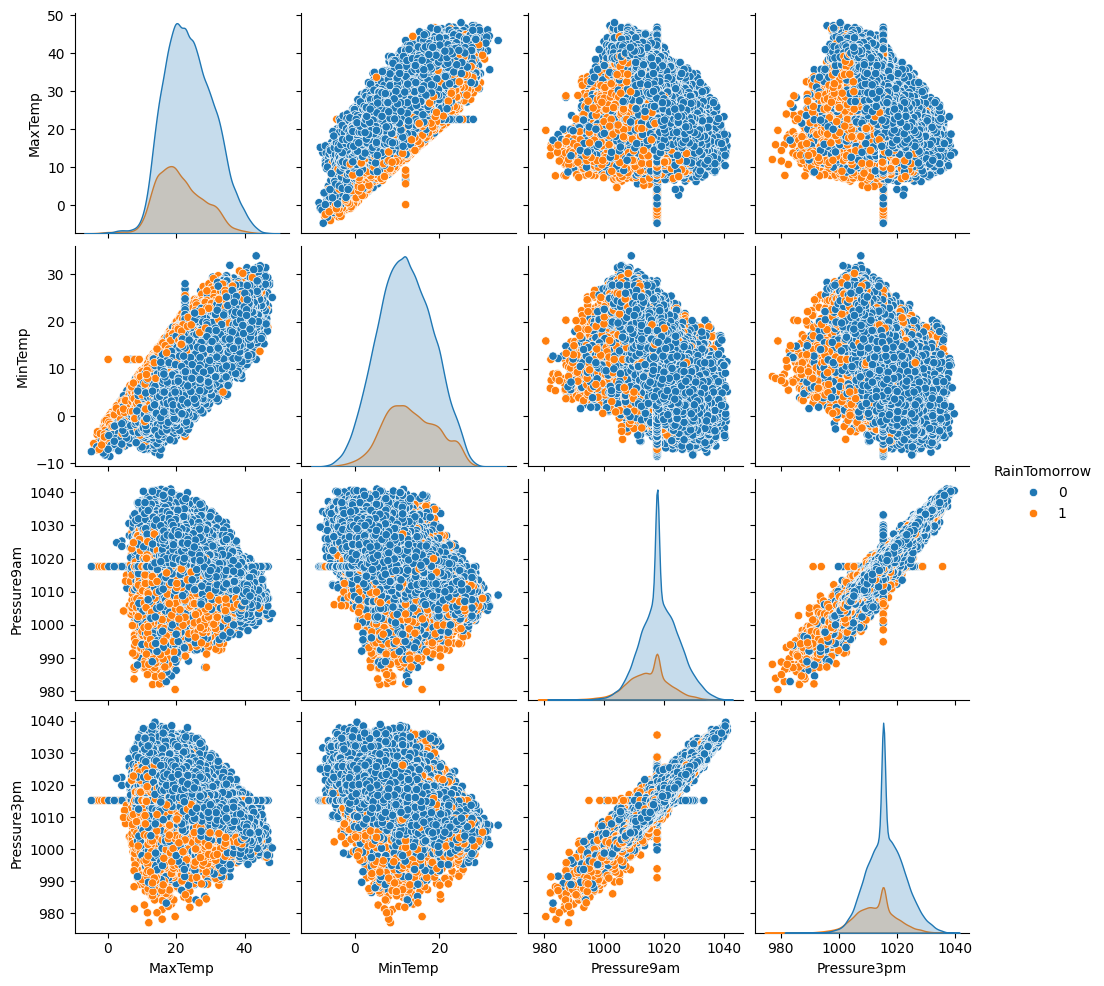

In [47]:
sns.pairplot(data=df_copy, vars=('MaxTemp','MinTemp','Pressure9am','Pressure3pm'), hue='RainTomorrow')
plt.show()

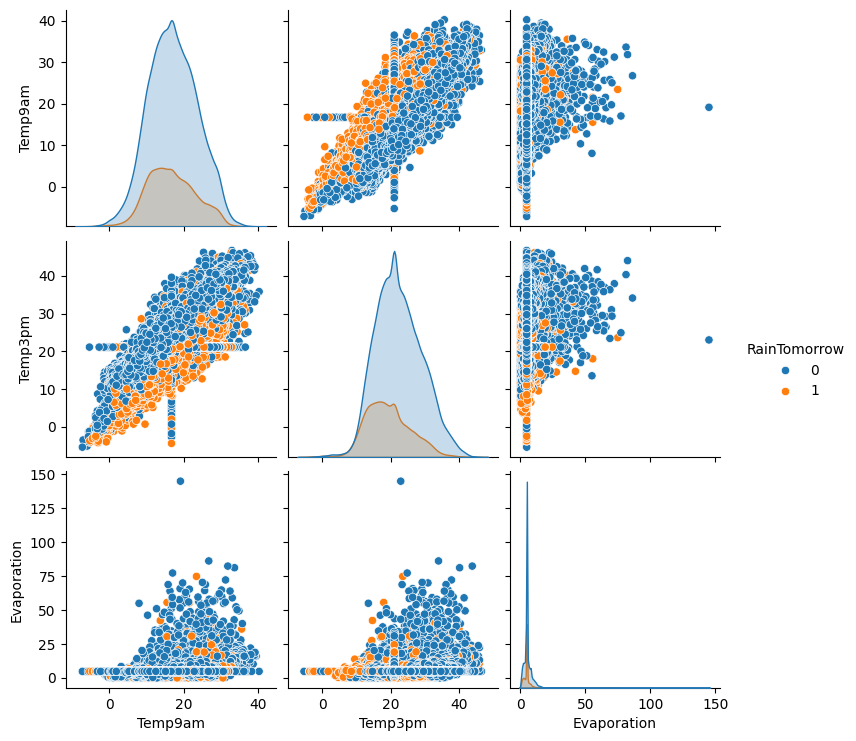

In [48]:
sns.pairplot(data=df_copy, vars=('Temp9am', 'Temp3pm', 'Evaporation'), hue='RainTomorrow')
plt.show()

# **Location-wise Average Climate Change Analysis**

## **Average WindSpeed Analysis**

In [237]:
windspeed_df = df_copy.groupby(['Location'], observed=False)[['WindSpeed9am', 'WindSpeed3pm']].mean()
windspeed_df = windspeed_df.reset_index()

fig = px.line(windspeed_df, x ='Location', y = windspeed_df.columns, title = 'Location vs Average WindSpeed', markers=True)
fig.update_yaxes(title_text = 'Windspeed')
fig.update_layout(xaxis=dict(tickangle=45, mirror = True))
fig.show()

 * There is significant variation in average wind speeds across different locations in Australia. Some locations consistently have higher average wind speeds than others.

* For most locations, the average wind speed at 3 pm (red line) is higher than the average wind speed at 9 am (blue line). This suggests a typical diurnal pattern where winds tend to pick up in the afternoon due to increased thermal activity.

* The gap between the blue and red lines indicates the average increase in wind speed from morning to afternoon. Some locations show a larger increase than others.

## **Average Humidity Analysis**

In [238]:
humidity_df = df_copy.groupby(['Location'], observed=False)[['Humidity9am', 'Humidity3pm']].mean()
humidity_df = humidity_df.reset_index()

fig = px.line(humidity_df, x ='Location', y = humidity_df.columns, title = 'Location vs Average Humidity', markers=True)
fig.update_yaxes(title_text = 'Humidity')
fig.update_layout(xaxis=dict(tickangle=45, mirror = True))
fig.show()

* There is considerable variation in average humidity levels across different locations in Australia. Some places are consistently more humid than others, both in the morning and afternoon.

* For almost all locations, the average humidity at 3 pm (red line) is lower than the average humidity at 9 am (blue line). This is a common diurnal pattern where humidity tends to decrease during the day as temperatures rise and the air's capacity to hold moisture increases.

* Locations with lower average humidity will show dips in both lines, suggesting drier climates, likely inland or desert regions.

* The vertical distance between the blue and red lines indicates the average drop in humidity from morning to afternoon. Some locations experience a much larger drop in humidity than others, which could be related to local climate factors and the intensity of daytime heating.

## **Average Pressure Analysis**

In [239]:
pressure_df = df_copy.groupby(['Location'], observed=False)[['Pressure9am', 'Pressure3pm']].mean()
pressure_df = pressure_df.reset_index()

fig = px.line(pressure_df, x ='Location', y = pressure_df.columns, title = 'Location vs Average Pressure', markers=True)
fig.update_yaxes(title_text = 'Humidity')
fig.update_layout(xaxis=dict(tickangle=45, mirror = True))
fig.show()

* The chart shows that average atmospheric pressure varies across different locations in Australia. Some locations tend to have higher or lower average pressure than others.

* For most locations, there is a slight decrease in average pressure from 9 am (blue line) to 3 pm (red line). This is a typical diurnal pattern related to the heating of the atmosphere during the day.

* High-pressure systems are often associated with stable, clear weather, while low-pressure systems can bring unsettled weather, including rain.

* The vertical distance between the blue and red lines indicates the average change in pressure from morning to afternoon. While this change is generally small compared to the overall pressure values, it can still be meteorologically significant.

## **Average Temperature Analysis**

In [240]:
temperature_df = df_copy.groupby(['Location'], observed=False)[['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']].mean()
temperature_df = temperature_df.reset_index()

fig = px.line(temperature_df, x ='Location', y = temperature_df.columns, title = 'Location vs Average Temperature', markers=True)
fig.update_yaxes(title_text = 'Temperature')
fig.update_layout(xaxis=dict(tickangle=45, mirror = True))
fig.show()

* This line plot visualizes the average minimum temperature (blue line), maximum temperature (orange line), 9 am temperature (green line), and 3 pm temperature (red line) for each location in the dataset.

* The chart clearly shows that average temperatures vary significantly across different locations in Australia, reflecting the diverse climate zones from cooler southern regions to warmer northern areas.

* The gap between the average minimum temperature (blue) and average maximum temperature (orange) lines for each location represents the average daily temperature range. Some locations have a much larger average daily range than others, which is typical for inland areas with less moderating influence from the ocean.

* For most locations, the average 9 am temperature (green) falls between the average minimum and maximum temperatures, and the average 3 pm temperature (red) is typically higher than the 9 am temperature but lower than the maximum temperature. This reflects the normal daily warming cycle.

* The difference between the average 9 am and 3 pm temperatures shows the average warming or cooling during that period.

In [241]:
# Deletes the DataFrame from the current session's memory to free up memory resources

del windspeed_df, humidity_df, pressure_df, temperature_df

# **Summary of Descriptive Analysis**

**Data Overview:**
*   The dataset contains a mix of categorical and numerical variables with some missing values.
*   Duplicate rows were checked and removed, though none were found.
*   Missing values were handled by dropping rows with missing 'RainToday' and 'RainTomorrow', and imputing remaining numerical missing values with the median and categorical missing values with empty strings.
*   The 'Date' column was converted to datetime and split into 'Day', 'Month', and 'Year'.
*   Several columns ('Date', 'WindGustDir', 'WindDir9am', 'WindDir3pm') were dropped as they were deemed less relevant.
*   Binary categorical variables ('RainToday', 'RainTomorrow') were identified for potential mapping to numerical values later.
*   Object data types were converted to 'category' for memory efficiency and better handling of categorical data.

**Target Variable Analysis (RainTomorrow):**
*   There are no missing values in the 'RainTomorrow' target variable after initial handling.
*   The variable has two unique values: 'No' and 'Yes'.
*   There is a significant class imbalance, with 'No' (no rain tomorrow) accounting for approximately 77.8% of observations and 'Yes' (rain tomorrow) accounting for approximately 22.2%. This imbalance will need to be considered during model building.

**Categorical Variables Analysis:**
*   Visualizations showed the frequency distribution of 'RainTomorrow', confirming the class imbalance.
*   Analyzing 'Location' against 'RainTomorrow' revealed that the frequency of rain predictions varies significantly by location, with major cities like Sydney, Canberra, and Melbourne showing higher counts of 'Yes' predictions.
*   The relationship between 'RainToday' and 'RainTomorrow' indicated a strong correlation, with a rainy day today making rain tomorrow more likely, although a significant number of dry days are also followed by rain.
*   Monthly and yearly rain patterns showed some seasonality, with higher percentages of rain predictions in cooler months, but overall proportions of 'Yes' and 'No' predictions remained relatively stable across years.

**Numerical Variables Distribution & Outlier Analysis:**
*   Histograms and Q-Q plots revealed that temperature and pressure variables are approximately normally distributed, while rainfall, evaporation, sunshine, and wind speed variables are heavily right-skewed with numerous outliers. Humidity variables show bimodal distributions.
*   Box plots by 'RainTomorrow' highlighted differences in distributions and outliers:
    *   Higher maximum temperatures and lower humidity (both 9 am and 3 pm) are more associated with no rain tomorrow.
    *   Higher wind gust speeds, lower pressure (both 9 am and 3 pm), and higher cloud cover (both 9 am and 3 pm) are more associated with rain tomorrow.
    *   Outliers were observed in various features, indicating extreme weather conditions are present in the dataset.

**Relationships Between Variables:**
*   Scatter plots revealed strong positive correlations between:
    *   Humidity9am and Humidity3pm (higher humidity throughout the day is linked to rain tomorrow).
    *   Pressure9am and Pressure3pm (lower pressure throughout the day is linked to rain tomorrow).
    *   MinTemp and MaxTemp (expected strong correlation).
*   An inverse relationship was observed between Cloud3pm and Sunshine, with higher cloud cover and lower sunshine hours being strongly associated with rain tomorrow.
*   Rainfall today showed a weak positive correlation with Humidity3pm and WindGustSpeed, with higher values in these features being more likely on days preceding rain, especially for higher rainfall amounts.

**Location-wise Average Climate Analysis:**
*   Line plots of average wind speed, humidity, pressure, and temperature across locations confirmed significant variations in these meteorological factors across Australia.
*   Typical diurnal patterns (higher wind speed and temperature in the afternoon, lower humidity and slightly lower pressure in the afternoon) were observed across most locations.

Overall, the descriptive analysis has provided valuable insights into the characteristics of the dataset, the distributions and relationships of various meteorological features, and how they relate to the target variable 'RainTomorrow'. Key predictors like Humidity3pm, Sunshine, Pressure9am, Pressure3pm, and WindGustSpeed show clear associations with the likelihood of rain tomorrow, which will be important for feature selection and model building. The class imbalance in the target variable is a significant factor to consider for the next steps.

# **Inferential Analysis**

In [396]:
# Get a copy of dataset for the analysis
df_inferential = df_cleaned.copy()

##HA1: Does humidity significantly differ between rainy and dry days?

In [397]:
# Get the data required
df_inferential['HumidityAvg'] = (df_inferential['Humidity9am'] + df_inferential['Humidity3pm'])/2
Humidity = df_inferential[['HumidityAvg', 'RainTomorrow']]
Humidity.head()

HumidityOnPredictedRain = Humidity[Humidity['RainTomorrow'] == 1]['HumidityAvg']
HumidityOnPredictedNoRain = Humidity[Humidity['RainTomorrow'] == 0]['HumidityAvg']

HumidityOnPredictedRain.head()

,HumidityAvg
8,25.5
10,35.0
11,90.0
12,84.5
16,75.5


since the dataset is large and >30, the T-test will perform well. But normality assesment is done to make sure that the set doesn't have large deviations, thus violating the normality conditions required for Paired sample T-test

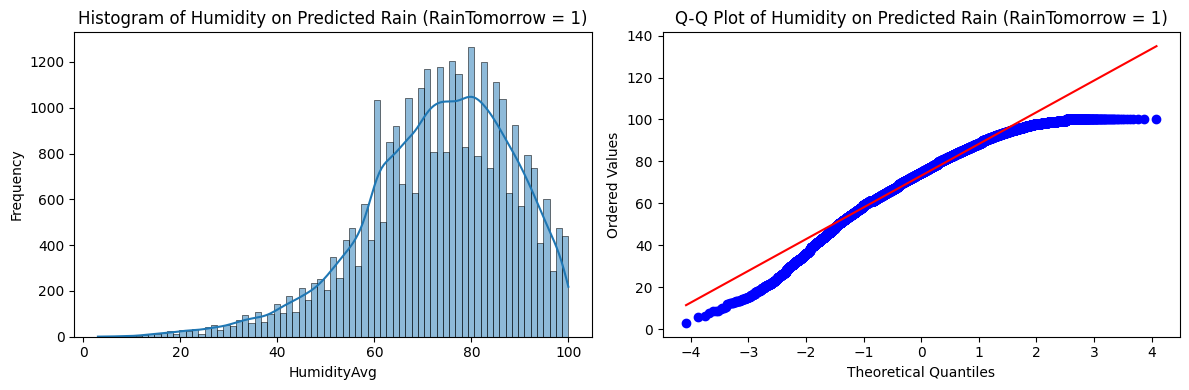

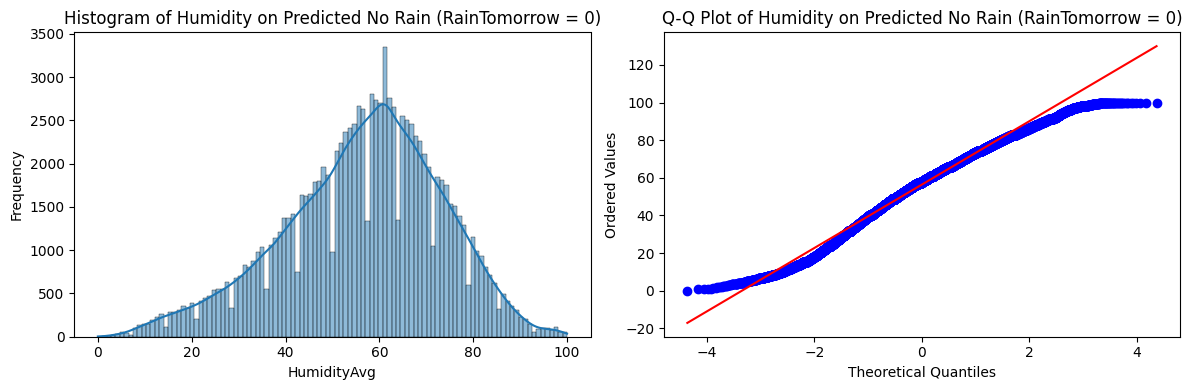

In [398]:
from scipy import stats
import math

cols = [HumidityOnPredictedRain, HumidityOnPredictedNoRain]
titles = ['Humidity on Predicted Rain (RainTomorrow = 1)', 'Humidity on Predicted No Rain (RainTomorrow = 0)']

for i, col in enumerate(cols):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(col, ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of {titles[i]}')
    axes[0].set_xlabel('HumidityAvg')
    axes[0].set_ylabel('Frequency')

    # Q-Q plot
    stats.probplot(col.dropna(), dist='norm', plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of {titles[i]}')
    axes[1].set_xlabel('Theoretical Quantiles')
    axes[1].set_ylabel('Ordered Values')

    plt.tight_layout()
    plt.show()

Since the deviation from the normality is higher, the Mann-whitney U test is chosen over paired sample T-test.
<br><br>

**Hypothesis Definition for Mann-whitney U test**

* H0 (Null hypothesis) = There is no difference in average humidity between days followed by rain and days not followed by rain.

* H1 (Alternative hypothesis) = There is a difference in average humidity between days followed by rain and days not followed by rain.

In [399]:
from scipy.stats import mannwhitneyu

# Perform Mann-Whitney U test
statistic, p_value = mannwhitneyu(HumidityOnPredictedRain, HumidityOnPredictedNoRain, alternative='greater')

# Print the results
print(f"Mann-Whitney U statistic: {statistic}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a difference in average humidity between days followed by rain and days not followed by rain.")
else:
    print("Fail to reject the null hypothesis: There is no difference in average humidity between days followed by rain and days not followed by rain.")

Mann-Whitney U statistic: 2646602549.0
P-value: 0.0
Reject the null hypothesis: There is a difference in average humidity between days followed by rain and days not followed by rain.


##HA2: Is rainfall today associated with the probability of rain tomorrow?

The the test perfomed on HA2 is to check the assosciation between the rain today and the rain tomorrow. The Chi-squared Test of Independance is used.

In [400]:
from scipy.stats import chi2_contingency

# Create a contingency table of RainToday and RainTomorrow
contingency_table = pd.crosstab(df_inferential['RainToday'], df_inferential['RainTomorrow'])
print(contingency_table)

RainTomorrow      0      1
RainToday                 
0             92728  16604
1             16858  14597


Since the two vriables are categorical, the Chi Squared test is used to assess the dependancy of tomorrows rain on the rain conditions of today.
<br><br>

**Hypothesis Definition for Chi Squared test**

* H0 (Null hypothesis) = Rainfall today does not have an effect on the rainfall tomorrow.

* H1 (Alternative hypothesis) = Rainfall today has an effect on the rainfall tomorrow.

In [401]:
# Perform the Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print the results
print("Results of the Chi-square test:")
print(f"Chi-square statistic = {chi2:.4f}")
print(f"Degrees of freedom = {dof}")
print(f"P-value = {p:.4f}\n")

print("Expected frequencies:")
print(expected)

alpha = 0.05
if p < alpha:
    print("\nReject the null hypothesis: Rainfall today has an effect on the rainfall tomorrow.")
else:
    print("\nFail to reject the null hypothesis: Rainfall today does not have an effect on the rainfall tomorrow.")

Results of the Chi-square test:
Chi-square statistic = 13799.4796
Degrees of freedom = 1
P-value = 0.0000

Expected frequencies:
[[85102.00907754 24229.99092246]
 [24483.99092246  6971.00907754]]

Reject the null hypothesis: Rainfall today has an effect on the rainfall tomorrow.


##HA3: Do average temperatures differ significantly between rainy and dry days?

In [402]:
# Get the data required
df_inferential['TempAvg'] = (df_inferential['Temp9am'] + df_inferential['Temp3pm'])/2
Temp = df_inferential[['TempAvg', 'RainTomorrow']]
Temp.head()

TempTodayOnPredictedRain = Temp[Temp['RainTomorrow'] == 1]['TempAvg']
TempTodayOnPredictedNoRain = Temp[Temp['RainTomorrow'] == 0]['TempAvg']

TempTodayOnPredictedRain.head()

,TempAvg
8,24.25
10,24.60
11,16.45
12,16.60
16,17.65


Since the dataset size > 30, we can proceed with the T-test. Before proceeding we will check for the normality using QQ plots since Shapiro-Wilk test is not pretty accurate for the given size of data (UserWarning: scipy.stats.shapiro: For N > 5000)

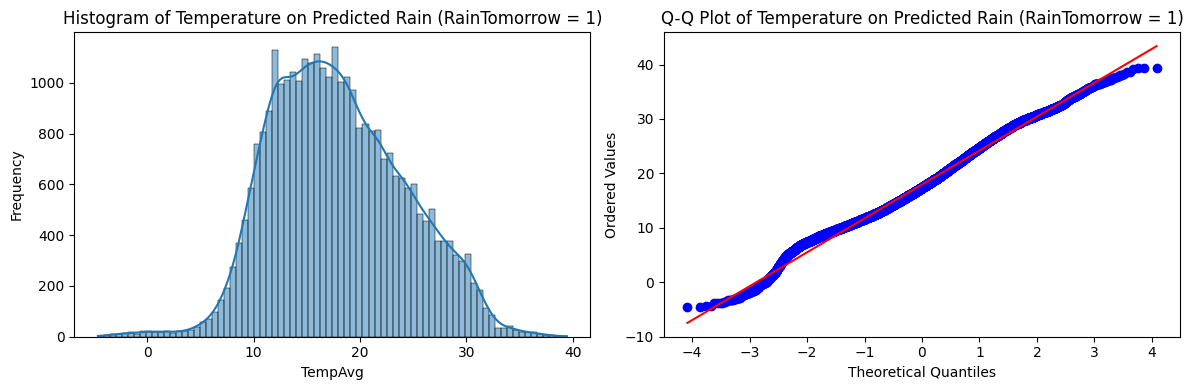

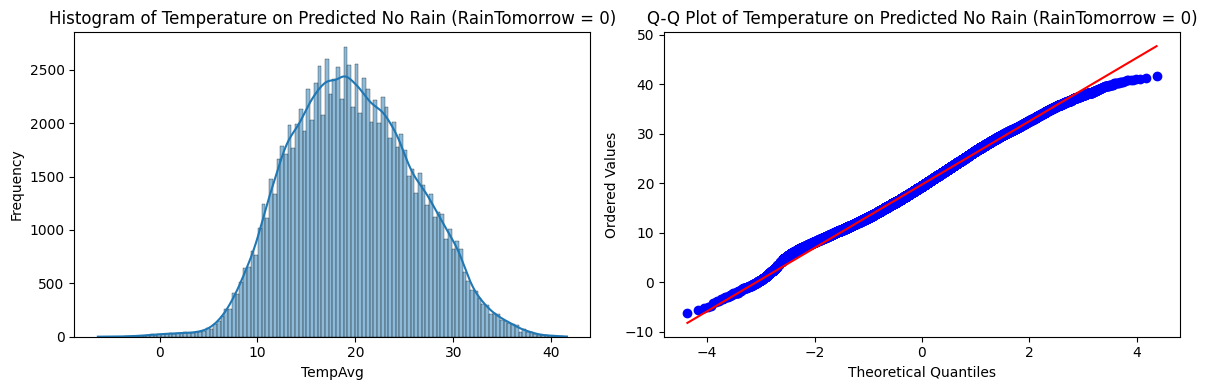

In [403]:
from scipy import stats
import math

cols = [TempTodayOnPredictedRain, TempTodayOnPredictedNoRain]
titles = ['Temperature on Predicted Rain (RainTomorrow = 1)', 'Temperature on Predicted No Rain (RainTomorrow = 0)']

for i, col in enumerate(cols):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(col, ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of {titles[i]}')
    axes[0].set_xlabel('TempAvg')
    axes[0].set_ylabel('Frequency')

    # Q-Q plot
    stats.probplot(col.dropna(), dist='norm', plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of {titles[i]}')
    axes[1].set_xlabel('Theoretical Quantiles')
    axes[1].set_ylabel('Ordered Values')

    plt.tight_layout()
    plt.show()

Since the dataset is large and almost normal we can proceed with the Paired Sample T-Test to test the association between the variables
<br><br>

**Hypothesis Definition for Paired sample T-Test**

*   H0 (Null hypothesis) = There is no difference in the distribution of average temperatures between days followed by rain and days not followed by rain.
*   H1 (Alternative hypothesis) = There is a difference in the distribution of average temperatures between days followed by rain and days not followed by rain.

In [404]:
# Perform paired sample T-Test
t_statistic, pvalue = stats.ttest_rel(df_inferential['TempAvg'], df_inferential['RainTomorrow'])

print("Results of the Chi-square test:")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {pvalue:.4f}")


alpha = 0.05
if p_value < alpha:
    print("\nReject the null hypothesis: There is a significant difference in the distribution of average temperatures between days followed by rain and days not followed by rain.")
else:
    print("\nFail to reject the null hypothesis: There is no significant difference in the distribution of average temperatures between days followed by rain and days not followed by rain.")

Results of the Chi-square test:
T-statistic: 1106.9262
P-value: 0.0000

Reject the null hypothesis: There is a significant difference in the distribution of average temperatures between days followed by rain and days not followed by rain.


##HA4: Is there a significant association between wind direction and rain occurrence?

In [405]:
# Get the data required
Wind = df_inferential[['WindGustDir', 'RainTomorrow']]
Wind.head()

WindTodayOnPredictedRain = Wind[Wind['RainTomorrow'] == 1]['WindGustDir']
WindTodayOnPredictedNoRain = Wind[Wind['RainTomorrow'] == 0]['WindGustDir']

WindTodayOnPredictedRain.head()

,WindGustDir
8,NNW
10,N
11,NNE
12,W
16,ENE


**Hypothesis Definition for Chi-Squared test**

*   H0 (Null hypothesis): Wind direction is independent of whether it rains tomorrow.
*   H1 (Alternative hypothesis): Wind direction is associated with whether it rains tomorrow.

In [406]:
from scipy.stats import chi2_contingency

# Create a contingency table of WindGustDir and RainTomorrow
contingency_table_wind = pd.crosstab(df_inferential['WindGustDir'], df_inferential['RainTomorrow'])

# Perform the Chi-square test
chi2_wind, p_wind, dof_wind, expected_wind = chi2_contingency(contingency_table_wind)

# Print the results
print("Results of the Chi-square test:")
print(f"Chi-square statistic: {chi2_wind:.4f}")
print(f"P-value: {p_wind:.4f}")
print(f"Degrees of freedom: {dof_wind}")

alpha = 0.05
if p_wind < alpha:
    print("\nReject the null hypothesis: Wind direction is associated with whether it rains tomorrow.")
else:
    print("\nFail to reject the null hypothesis: Wind direction is independent of whether it rains tomorrow.")

Results of the Chi-square test:
Chi-square statistic: 1593.4079
P-value: 0.0000
Degrees of freedom: 16

Reject the null hypothesis: Wind direction is associated with whether it rains tomorrow.


##HA5: Do rainfall amounts significantly vary between different cities?

In [407]:
from scipy.stats import f_oneway, kruskal
import seaborn as sns
import matplotlib.pyplot as plt

# Get the data required
top_cities = df_inferential["Location"].value_counts().index[:10]
subset = df_inferential[df_inferential["Location"].isin(top_cities)].dropna(subset=["Rainfall"])

# Prepare groups
groups = [subset[subset["Location"] == city]["Rainfall"] for city in top_cities]

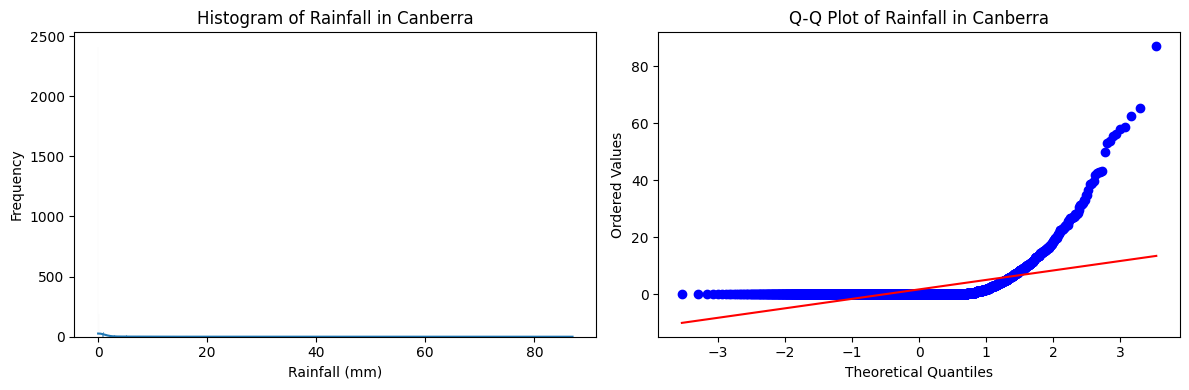

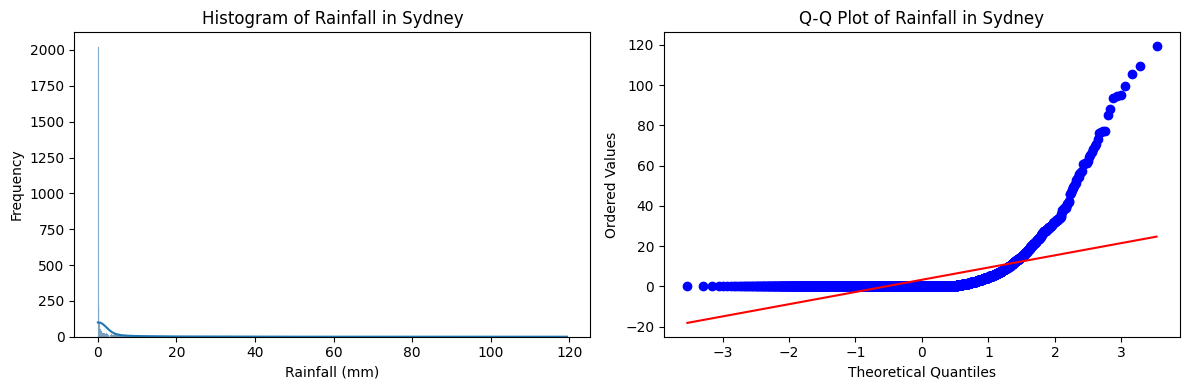

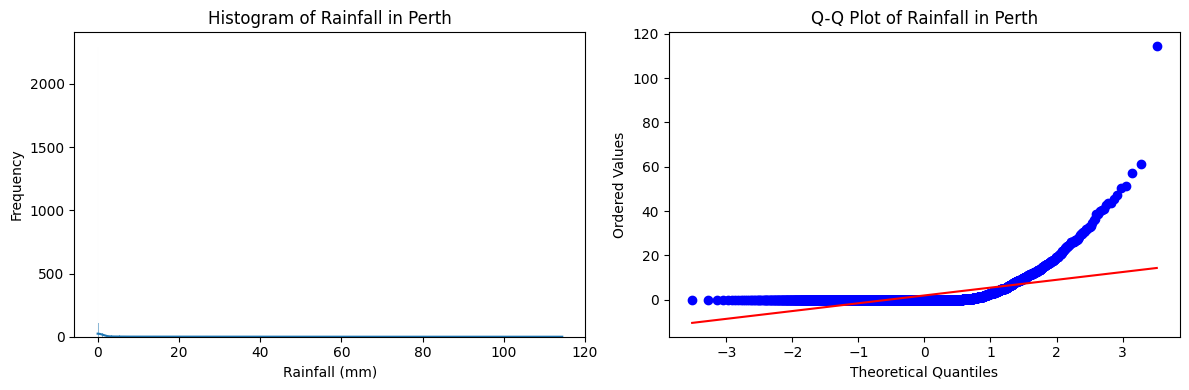

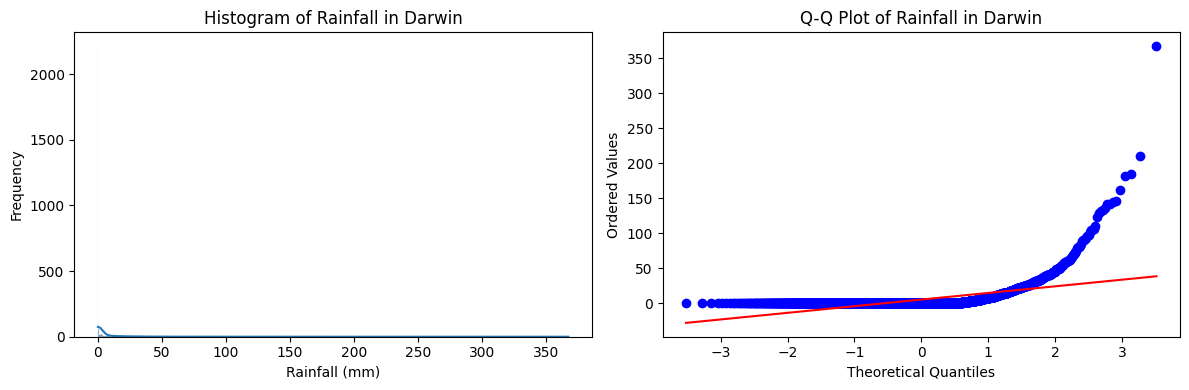

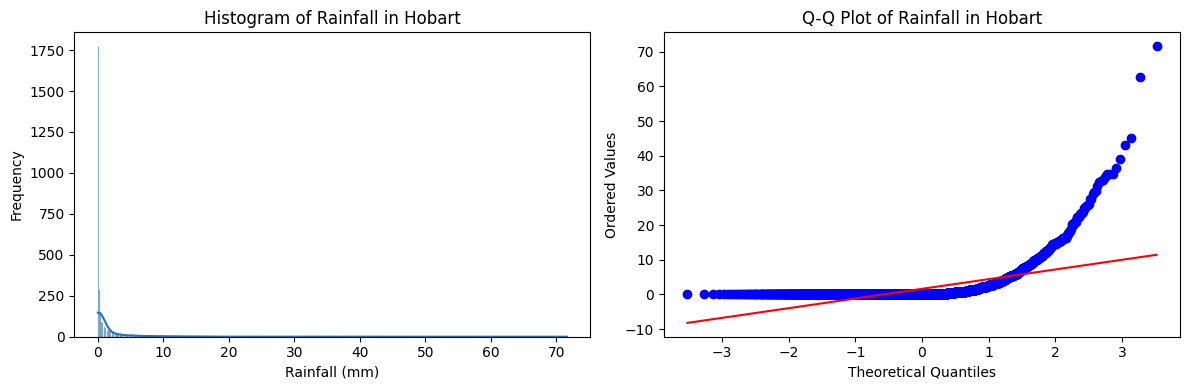

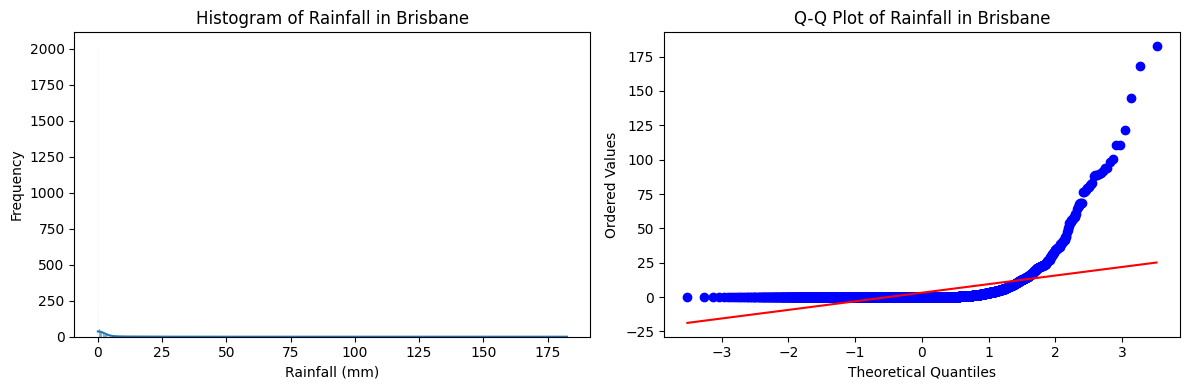

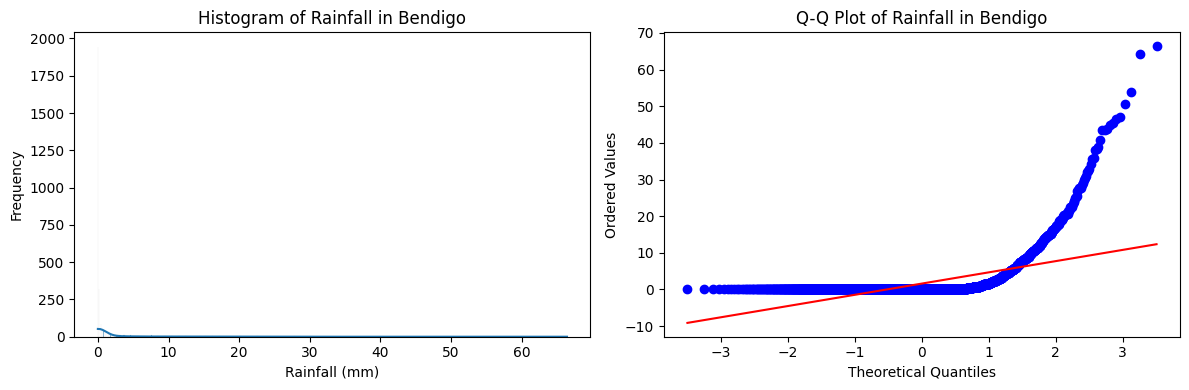

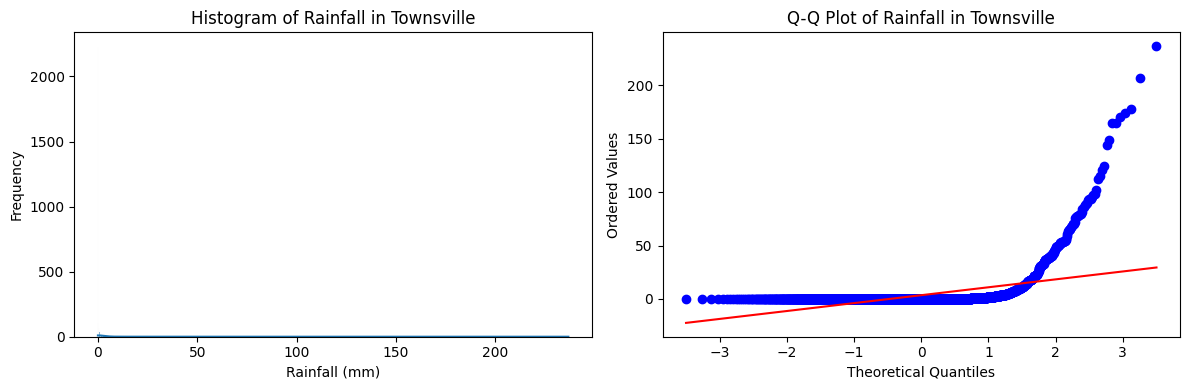

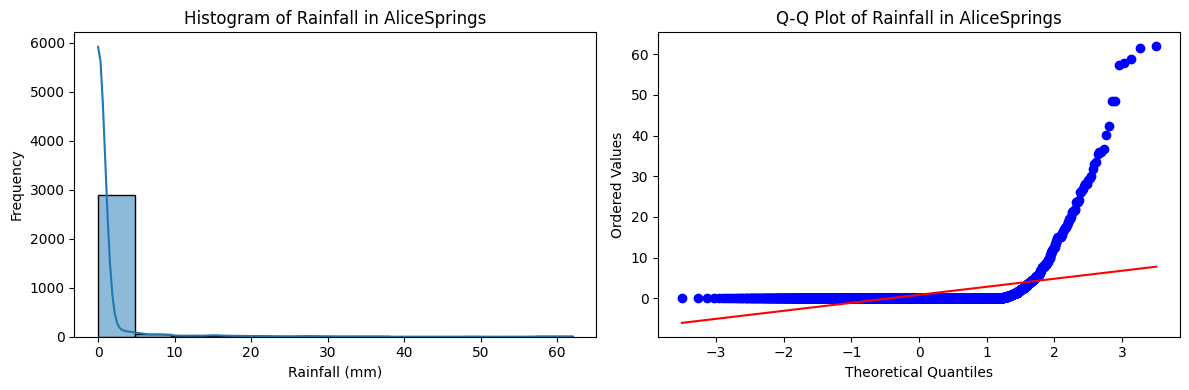

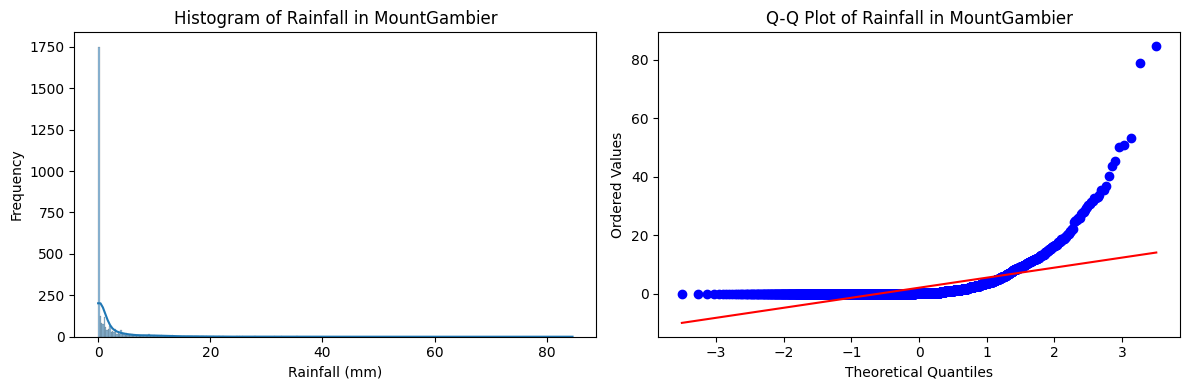

In [287]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

for city in top_cities:
    rainfall_data = subset[subset["Location"] == city]["Rainfall"].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(rainfall_data, ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of Rainfall in {city}')
    axes[0].set_xlabel('Rainfall (mm)')
    axes[0].set_ylabel('Frequency')

    # Q-Q plot
    stats.probplot(rainfall_data, dist='norm', plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of Rainfall in {city}')
    axes[1].set_xlabel('Theoretical Quantiles')
    axes[1].set_ylabel('Ordered Values')

    plt.tight_layout()
    plt.show()

Although the dataset is large the variables taken into consideration shows an extemely positive skewed behaviour the normality assumption violates. Therefor the Kruskal-Wallis is chosen over the ANOVA test
<br><br>

**Hypothesis Definition for Kruskal-Wallis test**

*   H0 (Null hypothesis) = There is no significant difference in rainfall distribution across the selected cities.
*   H1 (Alternative hypothesis) = There is a significant difference in rainfall distribution across the selected cities."

In [408]:
# Perform Kruskal-Wallis Test
h_stat, p_val_kruskal = kruskal(*groups)

print("Rainfall differences across cities (Kruskal-Wallis Test)")
print(f"H-statistic = {h_stat:.4f}")
print(f"p-value = {p_val_kruskal:.4f}\n")

alpha = 0.05
if p_val_kruskal < alpha:
  print("Reject the null hypothesis: There is a significant difference in rainfall distribution across the selected cities.")
else:
  print("Fail to reject the null hypothesis: There is no significant difference in rainfall distribution across the selected cities.")

Rainfall differences across cities (Kruskal-Wallis Test)
H-statistic = 1232.9982
p-value = 0.0000

Reject the null hypothesis: There is a significant difference in rainfall distribution across the selected cities.


Reject the null hypothesis: There is a significant difference in rainfall distribution across the selected cities.

# **Predictive Analysis**

In [453]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [454]:
df_cleaned.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [455]:
# Remove unwanted columns
df_cleaned.drop(['WindGustDir'], axis=1, inplace=True)
df_cleaned.drop(['Date'], axis=1, inplace=True)
df_cleaned.head()
df_cleaned.dropna()


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,NaN,NaN,44.0,W,WNW,20.0,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,NaN,NaN,44.0,NNW,WSW,4.0,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,NaN,NaN,46.0,W,WSW,19.0,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,NaN,NaN,24.0,SE,E,11.0,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,NaN,NaN,41.0,ENE,NW,7.0,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


Encoding Categorical Variables

In [447]:
# Include both 'category' and 'object' data types
categorical_cols = df_cleaned.select_dtypes(include=['category', 'object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

label_encoder = LabelEncoder()

for col in categorical_cols:
    df_cleaned[col] = label_encoder.fit_transform(df_cleaned[col])

print("\nData types after encoding:")
print(df_cleaned.dtypes)
df_cleaned.head()

Categorical columns to encode: []

Data types after encoding:
Location           int64
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustSpeed    float64
WindDir9am         int64
WindDir3pm         int64
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday          int64
RainTomorrow       int64
dtype: object


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2,13.4,22.9,0.6,NaN,NaN,44.0,13,14,20.0,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,0,0
1,2,7.4,25.1,0.0,NaN,NaN,44.0,6,15,4.0,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,0,0
2,2,12.9,25.7,0.0,NaN,NaN,46.0,13,15,19.0,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,0,0
3,2,9.2,28.0,0.0,NaN,NaN,24.0,9,0,11.0,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,0,0
4,2,17.5,32.3,1.0,NaN,NaN,41.0,1,7,7.0,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0,0


Define Features (X) and Target (Y)

In [429]:
y = df_cleaned['RainTomorrow']

X = df_cleaned.drop(['RainTomorrow', 'RainToday'], axis=1)

print("Shape of Features (X):", X.shape)
print("Shape of Target (y):", y.shape)

Shape of Features (X): (140787, 20)
Shape of Target (y): (140787,)


Data Splitting

In [430]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 112629 rows
Testing set size: 28158 rows


Scaling Features

In [432]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training the model


In [460]:
log_reg = LogisticRegression(random_state=42, max_iter=1000) # max_iter increased for convergence
rf = RandomForestClassifier(random_state=42, n_estimators=100)
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

print("Training Logistic Regression...")
log_reg.fit(X_train_scaled, y_train)

print("Training Random Forest...")
rf.fit(X_train_scaled, y_train)

print("Training XGBoost...")
xgb.fit(X_train_scaled, y_train)

print("All models trained successfully!")

Training Logistic Regression...


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Evaluate Model Performances

In [143]:
y_pred_log_reg = log_reg.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)
y_pred_xgb = xgb.predict(X_test_scaled)

# Function to print evaluation metrics nicely
def evaluate_model(model_name, y_true, y_pred):
    print(f"\n\033[1m{model_name} Performance:\033[0m") # \033[1m is for bold text
    accuracy = accuracy_score(y_true, y_pred)
    print("Accuracy:", round(accuracy, 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    roc_auc = roc_auc_score(y_true, y_pred)
    print("ROC-AUC Score:", round(roc_auc, 4))
    print("----------------------------------")

evaluate_model("Logistic Regression", y_test, y_pred_log_reg)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)


Logistic Regression Performance:
Accuracy: 0.8362

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90     21897
           1       0.71      0.45      0.55      6261

    accuracy                           0.84     28158
   macro avg       0.78      0.70      0.72     28158
weighted avg       0.82      0.84      0.82     28158

ROC-AUC Score: 0.6974
----------------------------------

Random Forest Performance:
Accuracy: 0.8525

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     21897
           1       0.76      0.49      0.60      6261

    accuracy                           0.85     28158
   macro avg       0.81      0.72      0.75     28158
weighted avg       0.84      0.85      0.84     28158

ROC-AUC Score: 0.7231
----------------------------------

XGBoost Performance:
Accuracy: 0.8545

Classification Report:
              precision  

Addressing Class Imbalance

In [144]:
from sklearn.utils import class_weight

classes = np.unique(y_train)
class_weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, class_weights))

print("Class weights:", class_weights_dict)

log_reg_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight=class_weights_dict)
rf_balanced = RandomForestClassifier(random_state=42, n_estimators=100, class_weight=class_weights_dict)
xgb_balanced = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=class_weights_dict[1])

print("Training balanced models...")
log_reg_balanced.fit(X_train_scaled, y_train)
rf_balanced.fit(X_train_scaled, y_train)
xgb_balanced.fit(X_train_scaled, y_train)
print("Balanced models trained!")

Class weights: {np.int64(0): np.float64(0.6422071183386742), np.int64(1): np.float64(2.257999198075381)}
Training balanced models...
Balanced models trained!


Evaluating the Balanced Module

In [145]:
y_pred_log_reg_bal = log_reg_balanced.predict(X_test_scaled)
y_pred_rf_bal = rf_balanced.predict(X_test_scaled)
y_pred_xgb_bal = xgb_balanced.predict(X_test_scaled)

print("\n\033[1m=== BALANCED MODEL RESULTS ===\033[0m")
evaluate_model("Balanced Logistic Regression", y_test, y_pred_log_reg_bal)
evaluate_model("Balanced Random Forest", y_test, y_pred_rf_bal)
evaluate_model("Balanced XGBoost", y_test, y_pred_xgb_bal)


=== BALANCED MODEL RESULTS ===

Balanced Logistic Regression Performance:
Accuracy: 0.7738

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.78      0.84     21897
           1       0.49      0.75      0.60      6261

    accuracy                           0.77     28158
   macro avg       0.71      0.77      0.72     28158
weighted avg       0.82      0.77      0.79     28158

ROC-AUC Score: 0.7657
----------------------------------

Balanced Random Forest Performance:
Accuracy: 0.849

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     21897
           1       0.77      0.46      0.57      6261

    accuracy                           0.85     28158
   macro avg       0.82      0.71      0.74     28158
weighted avg       0.84      0.85      0.83     28158

ROC-AUC Score: 0.7084
----------------------------------

Balanced XGBoost Performance:
Accuracy

Using Different Probability Thresholds

In [146]:
y_proba_xgb = xgb_balanced.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.3, 0.4, 0.5]
for threshold in thresholds:
    y_pred_threshold = (y_proba_xgb >= threshold).astype(int)
    print(f"\n\033[1mXGBoost with threshold {threshold}:\033[0m")
    print("Recall for 'Rain' class:", classification_report(y_test, y_pred_threshold, output_dict=True)['1']['recall'])
    print("Precision for 'Rain' class:", classification_report(y_test, y_pred_threshold, output_dict=True)['1']['precision'])


XGBoost with threshold 0.3:
Recall for 'Rain' class: 0.8524197412553906
Precision for 'Rain' class: 0.4892739273927393

XGBoost with threshold 0.4:
Recall for 'Rain' class: 0.7724005749880211
Precision for 'Rain' class: 0.5566939104408887

XGBoost with threshold 0.5:
Recall for 'Rain' class: 0.6896661875099824
Precision for 'Rain' class: 0.6239884393063584


Feature Importance Analysis

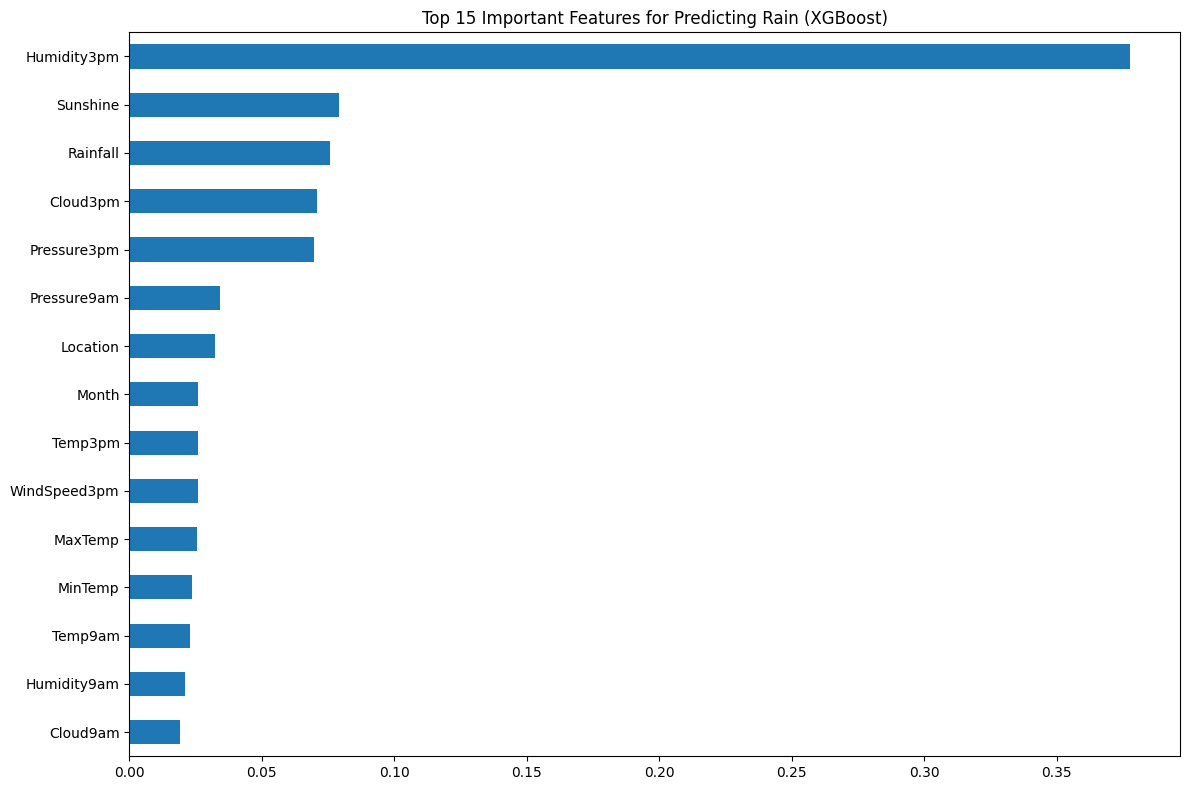

In [147]:
plt.figure(figsize=(12, 8))
feature_importances = pd.Series(xgb_balanced.feature_importances_, index=X.columns)
feature_importances.nlargest(15).sort_values().plot(kind='barh')
plt.title('Top 15 Important Features for Predicting Rain (XGBoost)')
plt.tight_layout()
plt.show()

Confusion Matrix

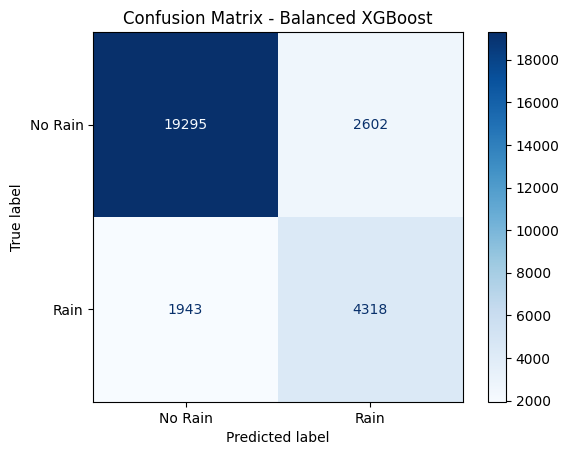

In [148]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb_bal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rain', 'Rain'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Balanced XGBoost')
plt.show()

Hyperparameter Tuning (XGBoost)

In [149]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'scale_pos_weight': [3, 5, 7]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

print("Starting grid search...")
grid_search.fit(X_train_scaled, y_train)
print("Grid search complete!")

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC score from cross-validation: {grid_search.best_score_:.4f}")

best_xgb_model = grid_search.best_estimator_

Starting grid search...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Grid search complete!

Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'scale_pos_weight': 3}
Best ROC-AUC score from cross-validation: 0.8845


Final Evaluation of the Tuned Model

In [150]:
y_pred_best_xgb = best_xgb_model.predict(X_test_scaled)
y_proba_best_xgb = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

print("\n\033[1m=== TUNED XGBoost Model Results ===\033[0m")
evaluate_model("Tuned XGBoost", y_test, y_pred_best_xgb)

roc_auc_best = roc_auc_score(y_test, y_proba_best_xgb)
print(f"ROC-AUC Score (with probabilities): {roc_auc_best:.4f}")


=== TUNED XGBoost Model Results ===

Tuned XGBoost Performance:
Accuracy: 0.8216

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88     21897
           1       0.58      0.75      0.65      6261

    accuracy                           0.82     28158
   macro avg       0.75      0.80      0.77     28158
weighted avg       0.84      0.82      0.83     28158

ROC-AUC Score: 0.7952
----------------------------------
ROC-AUC Score (with probabilities): 0.8850


Analyze the Best Model Behaviour

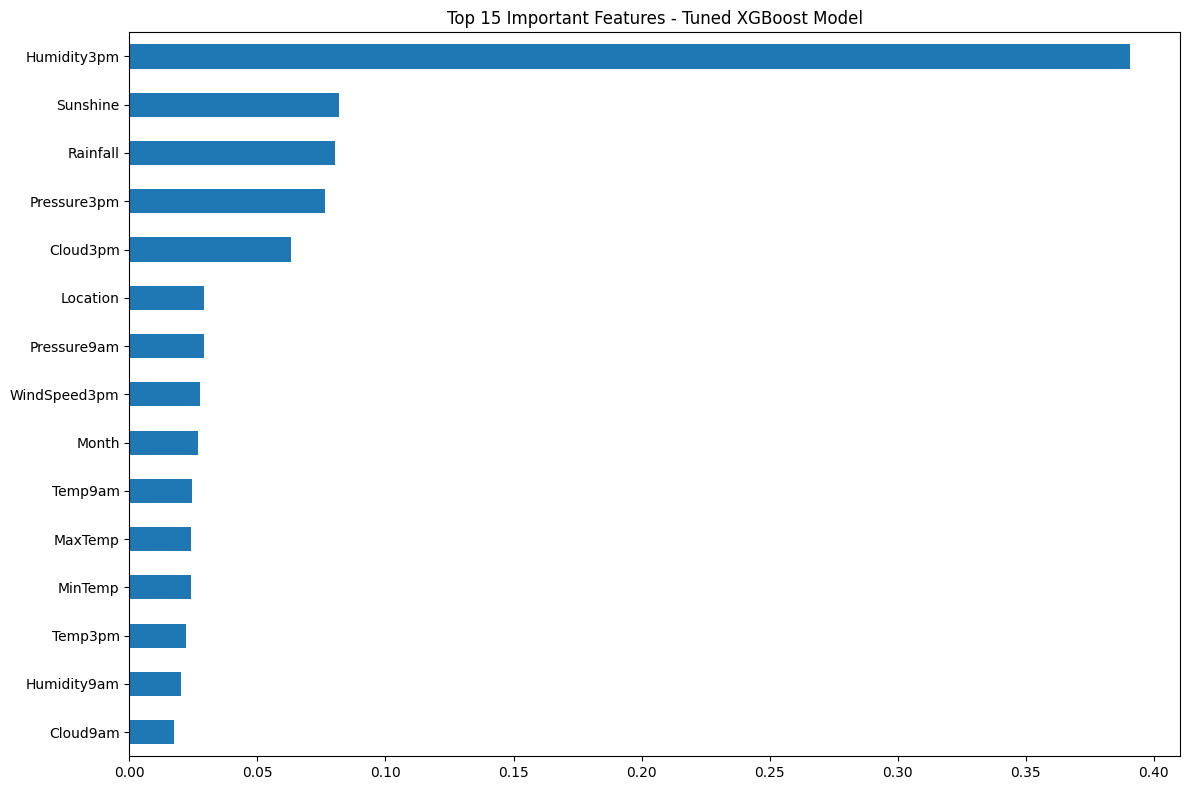

Top 10 Most Important Features for Predicting RainTomorrow:
Humidity3pm     0.390693
Sunshine        0.081721
Rainfall        0.080282
Pressure3pm     0.076225
Cloud3pm        0.062949
Location        0.029166
Pressure9am     0.029045
WindSpeed3pm    0.027499
Month           0.026950
Temp9am         0.024558
dtype: float32


In [151]:
plt.figure(figsize=(12, 8))
importances = pd.Series(best_xgb_model.feature_importances_, index=X.columns)
importances.nlargest(15).sort_values().plot(kind='barh')
plt.title('Top 15 Important Features - Tuned XGBoost Model')
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features for Predicting RainTomorrow:")
print(importances.nlargest(10))

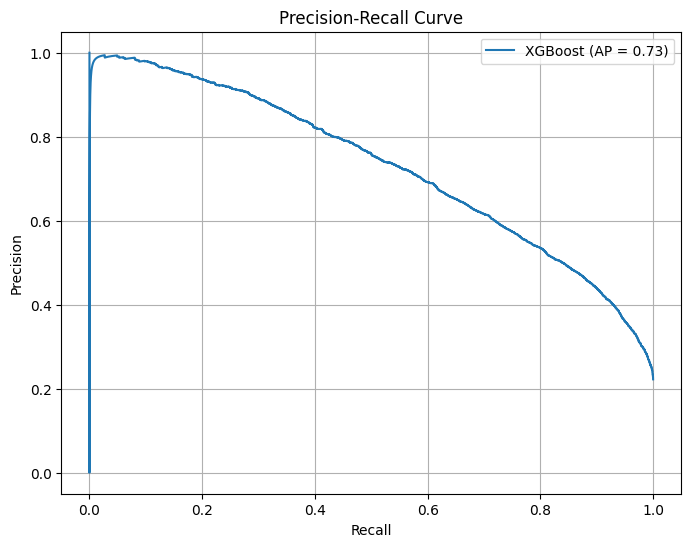

In [152]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_best_xgb)
average_precision = average_precision_score(y_test, y_proba_best_xgb)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'XGBoost (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

Sample Predictions

In [153]:
print("=== DEBUGGING FEATURE MISMATCH ===")
print(f"Number of features in X_train: {X_train.shape[1]}")
print(f"Number of features scaler expects: {scaler.n_features_in_}")
print("\nList of all features the model is actually using:")
print(X.columns.tolist())
print(f"\nTotal features: {len(X.columns)}")

=== DEBUGGING FEATURE MISMATCH ===
Number of features in X_train: 19
Number of features scaler expects: 19

List of all features the model is actually using:
['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Day', 'Month', 'Year']

Total features: 19


In [154]:
print("=== MAKING A SAMPLE PREDICTION ===")

sample_data = {}
for feature in X.columns:
    sample_data[feature] = [X_train[feature].median()]

new_data_df = pd.DataFrame(sample_data)
print("Sample data point (median values for all features):")
print(new_data_df)

new_data_scaled = scaler.transform(new_data_df)

prediction = best_xgb_model.predict(new_data_scaled)
prediction_proba = best_xgb_model.predict_proba(new_data_scaled)

print(f"\nPrediction for 'average' conditions:")
print(f"Probability of No Rain: {prediction_proba[0][0]:.2%}")
print(f"Probability of Rain: {prediction_proba[0][1]:.2%}")
print(f"Final Prediction: {'Rain Tomorrow' if prediction[0] == 1 else 'No Rain Tomorrow'}")

=== MAKING A SAMPLE PREDICTION ===
Sample data point (median values for all features):
   Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindSpeed9am  \
0      24.0     12.0     22.6       0.0          4.8       8.5          13.0   

   WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  \
0          19.0         70.0         52.0       1017.6       1015.2       5.0   

   Cloud3pm  Temp9am  Temp3pm   Day  Month    Year  
0       5.0     16.7     21.1  16.0    6.0  2013.0  

Prediction for 'average' conditions:
Probability of No Rain: 65.95%
Probability of Rain: 34.05%
Final Prediction: No Rain Tomorrow


In [155]:
print("\n=== TESTING A 'RAINY' SCENARIO ===")

rainy_scenario = sample_data.copy()

if 'Humidity3pm' in rainy_scenario:
    rainy_scenario['Humidity3pm'] = [90]
if 'Pressure3pm' in rainy_scenario:
    rainy_scenario['Pressure3pm'] = [990]
if 'Cloud3pm' in rainy_scenario:
    rainy_scenario['Cloud3pm'] = [8]

rainy_df = pd.DataFrame(rainy_scenario)
rainy_scaled = scaler.transform(rainy_df)
rainy_pred = best_xgb_model.predict(rainy_scaled)
rainy_proba = best_xgb_model.predict_proba(rainy_scaled)

print("Sample data point for 'rainy' conditions:")
print(rainy_df[['Humidity3pm', 'Pressure3pm', 'Cloud3pm']])
print(f"\nPrediction for 'rainy' conditions:")
print(f"Probability of No Rain: {rainy_proba[0][0]:.2%}")
print(f"Probability of Rain: {rainy_proba[0][1]:.2%}")
print(f"Final Prediction: {'Rain Tomorrow' if rainy_pred[0] == 1 else 'No Rain Tomorrow'}")


=== TESTING A 'RAINY' SCENARIO ===
Sample data point for 'rainy' conditions:
   Humidity3pm  Pressure3pm  Cloud3pm
0           90          990         8

Prediction for 'rainy' conditions:
Probability of No Rain: 1.28%
Probability of Rain: 98.72%
Final Prediction: Rain Tomorrow




---

# ***Group 02 - Members***

1. Sandaru Senitha - FC211021
2. Dilini Sewwandi - FC211041
3. Aashinshana Weerakoon - FC211015